## Import

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [ ]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [ ]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "Base"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [ ]:
override = False
use_preds = True
save = True
show = True

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


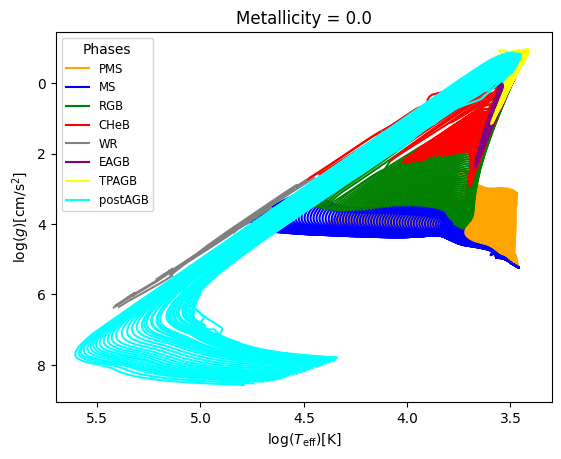

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
630600,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
630601,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
630602,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
630603,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


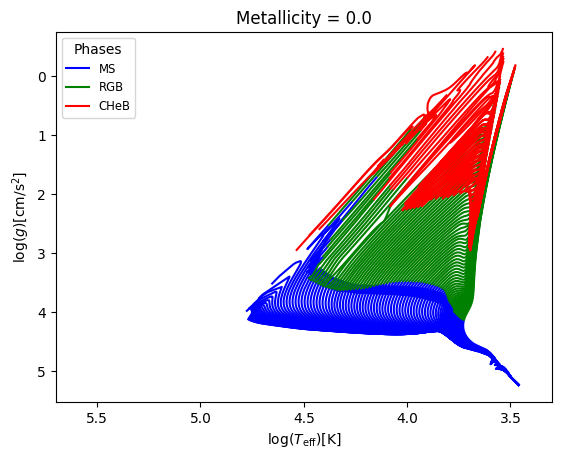

In [6]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [7]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.1154, Median : 8.15

log_Teff  : Range : 3.34 - 5.3788, Mean : 4.0283, Median : 3.9761

log_g  : Range : -1.08 - 6.2594, Mean : 3.5075, Median : 3.8521

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 298.5448, Mean : 11.4145, Median : 2.8996

log_R  : Range : -1.0 - 3.1298, Mean : 0.735, Median : 0.7005



In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 298.5447575808816
Median value in train data for the star_mass parameter: 2.900660435695107
Mean value in train data for the star_mass parameter: 11.448959764246645

Range in train data for the log_R parameter : -0.9974628481553472 - 3.129269620812593
Median value in train data for the log_R parameter: 0.7005259212303901
Mean value in train data for the log_R parameter: 0.7346615625058007

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999984244466985 - 295.93050489035244
Median value in test data for the star_mass parameter: 2.89581954298918
Mean value in test data for the star_mass parameter: 11.31127918999169

Range in test data for the log_R parameter : -0.9974747647513328 - 3.1297545143214007
Median value in test data for the log_R parameter: 0.700308157259431
Mean value in test data for the log_R parameter: 0.7362027655401773

(472953, 4) (157652, 4)
(47295

## Model training

### Linear regression

In [9]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.2728709030098654
  RMSE :  22.429900129172562
  MAE :  13.107804483635931
  MedAE :  11.253017830833237
  CORR :  0.5343027371731521
  MAX_ER :  257.50847847048124
  Percentiles : 
    75th percentile :  15.423789353894316
    90th percentile :  18.517408532832775
    95th percentile :  20.734048636668735
    99th percentile :  102.34281786807915

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.3168817813892185
  RMSE :  24.543023748412015
  MAE :  10.23576274299457
  MedAE :  5.268355111684988
  CORR :  0.5956286032810738
  MAX_ER :  247.1328209413902
  Percentiles : 
    75th percentile :  11.237111436499081
    90th percentile :  14.43747989151886
    95th percentile :  23.01619817363136
    99th percentile :  137.7606643260659

mass results 

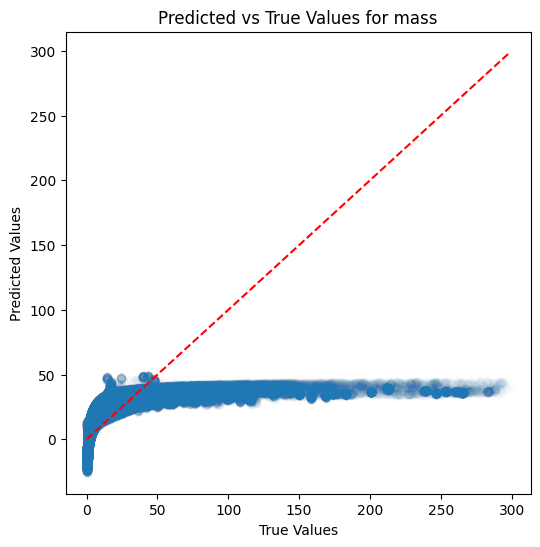

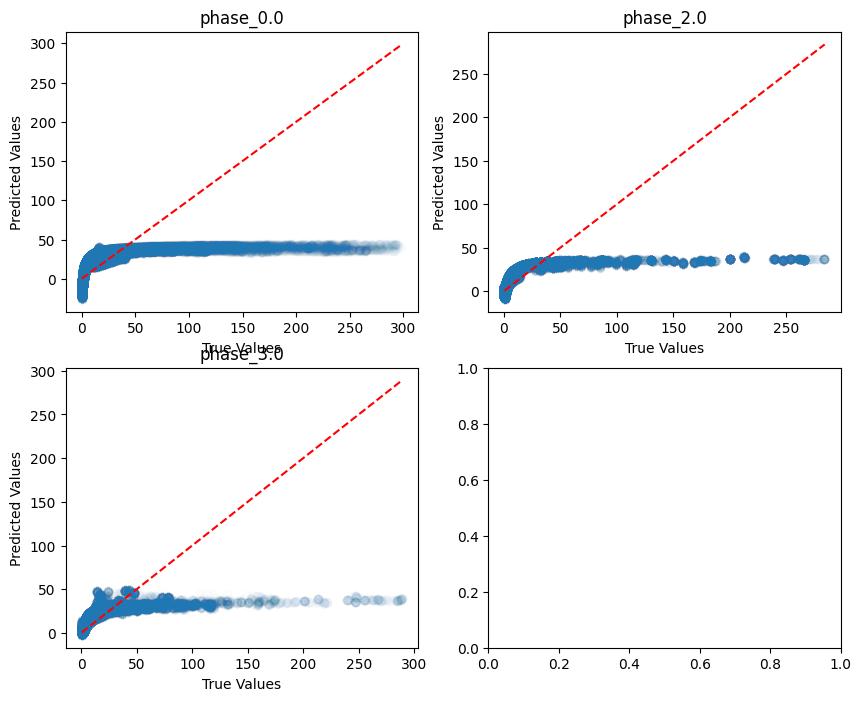

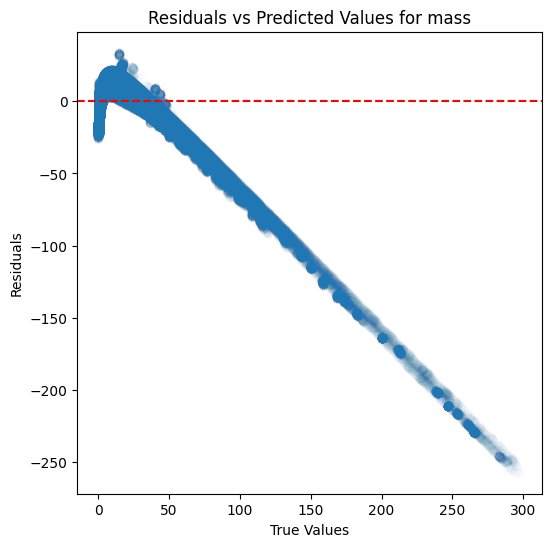

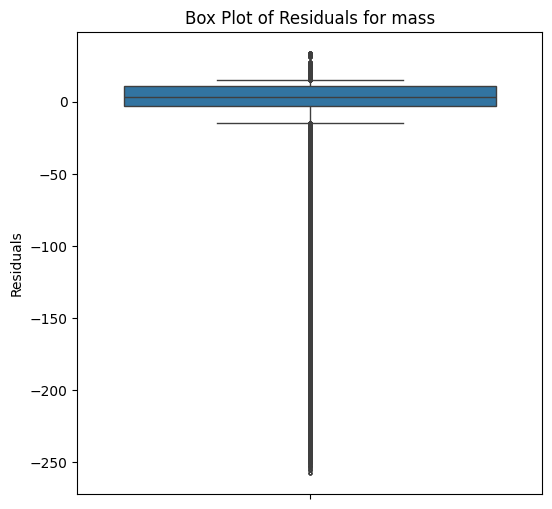

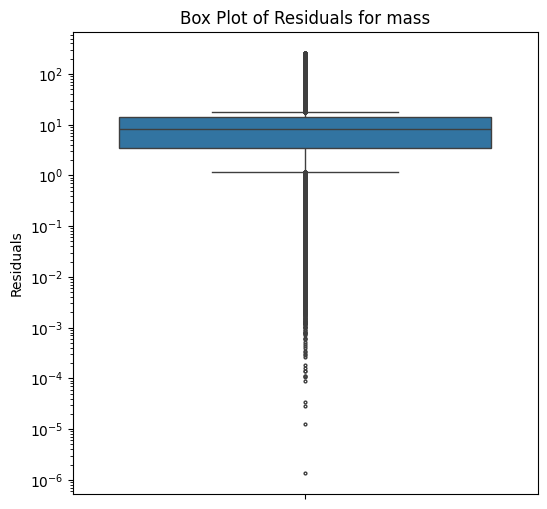

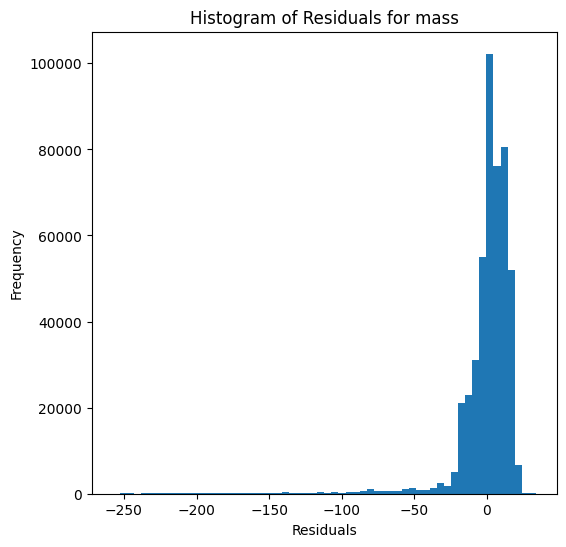

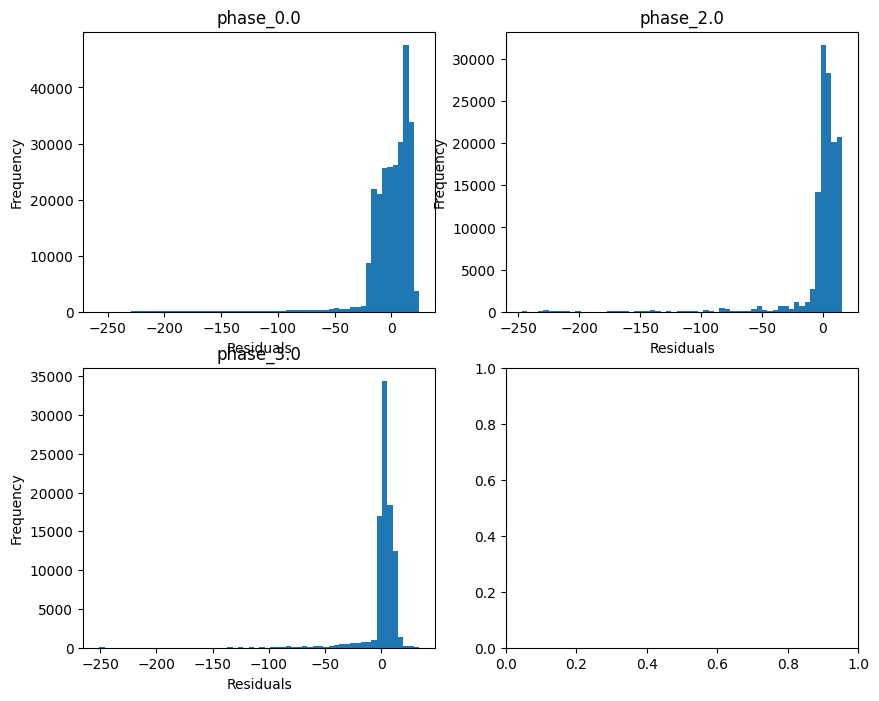

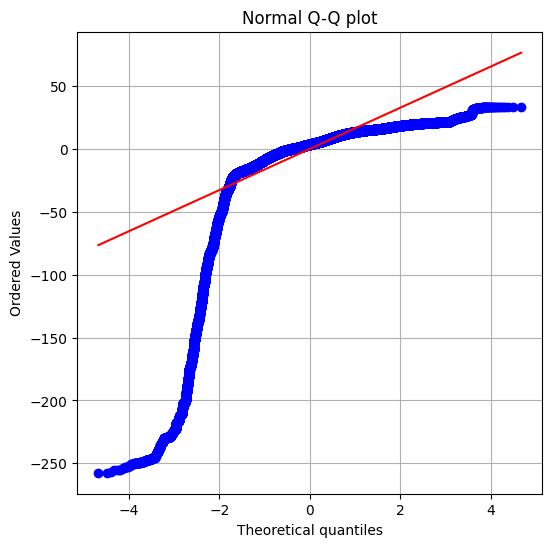

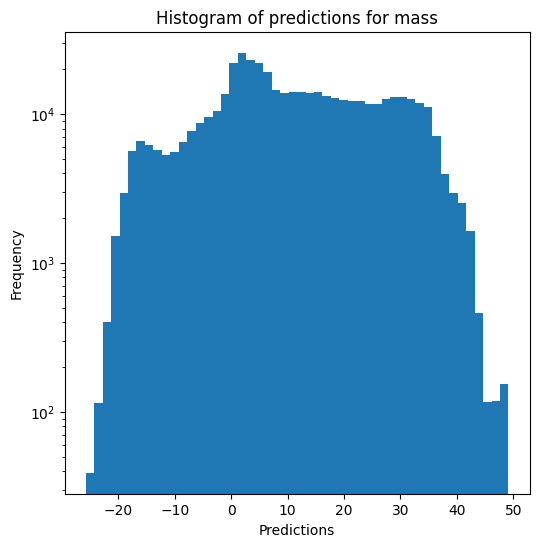

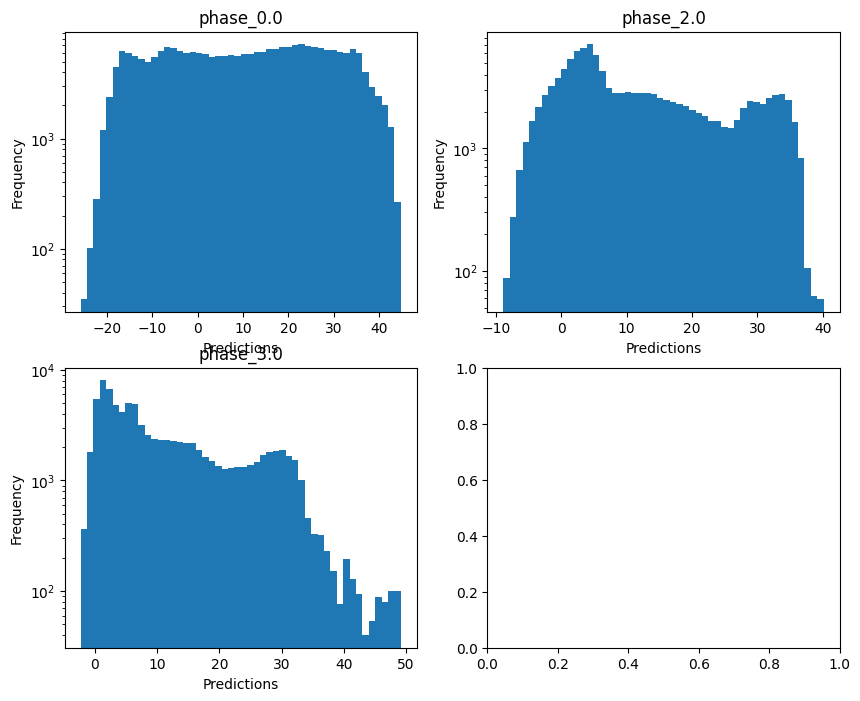

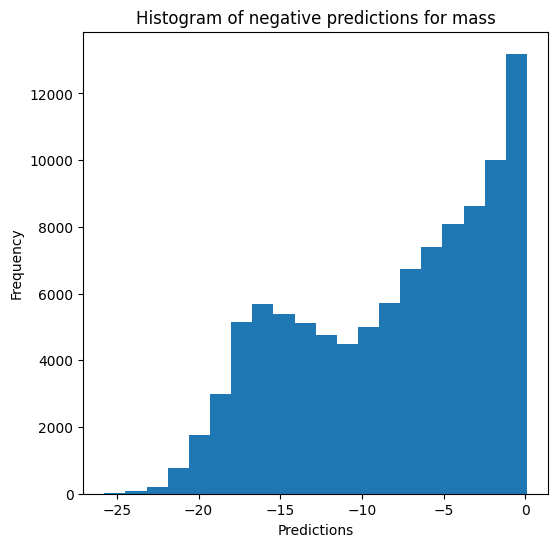


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9778146729622458
  RMSE :  0.08499169455949242
  MAE :  0.06644057676881247
  MedAE :  0.052470644163374436
  CORR :  0.9888944199376599
  MAX_ER :  0.45807766995922083
  Percentiles : 
    75th percentile :  0.09619903944971864
    90th percentile :  0.13469965074636725
    95th percentile :  0.15727958575246567
    99th percentile :  0.2505204276476863

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9679744997103377
  RMSE :  0.0884158297132134
  MAE :  0.057736628688100165
  MedAE :  0.03394437787640836
  CORR :  0.9838665758685889
  MAX_ER :  0.452908397569574
  Percentiles : 
    75th percentile :  0.07349899037494612
    90th percentile :  0.14129835891614495
    95th percentile :  0.19408078671043355
    99th percentile :  0.35002097849302344

radius results for the phase cate

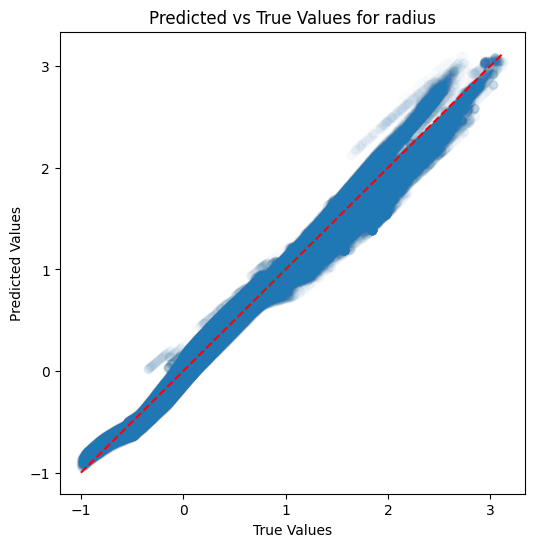

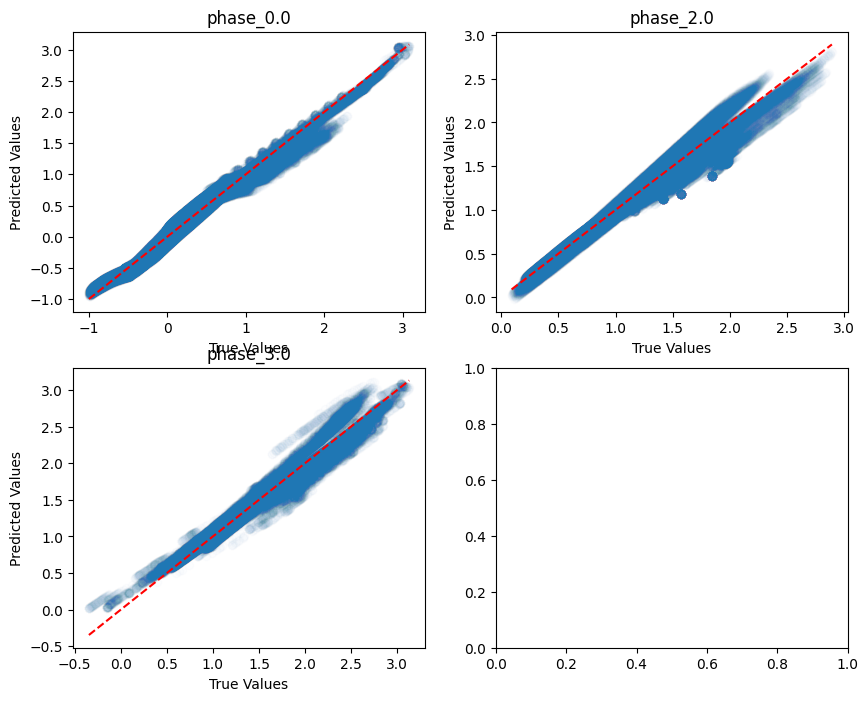

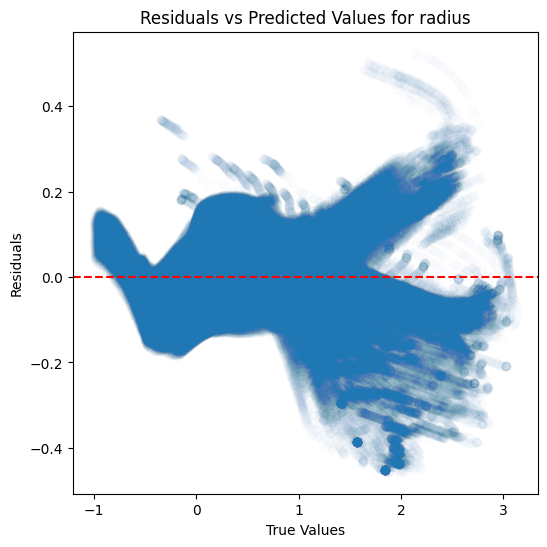

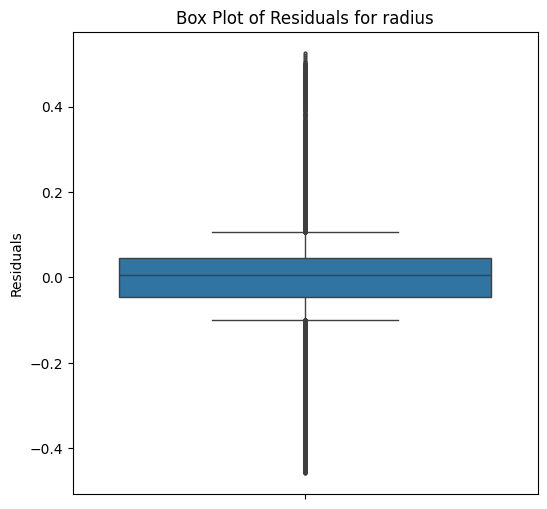

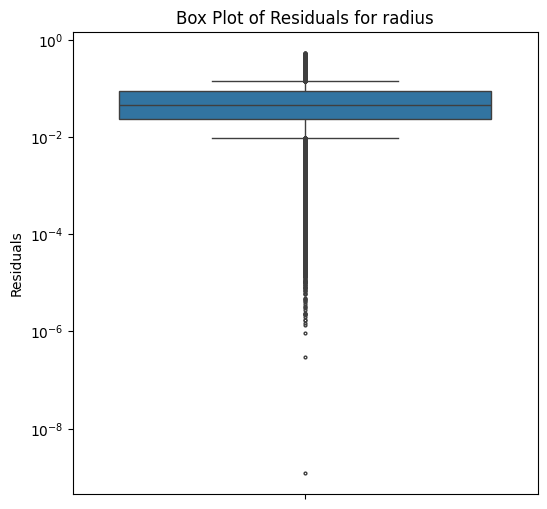

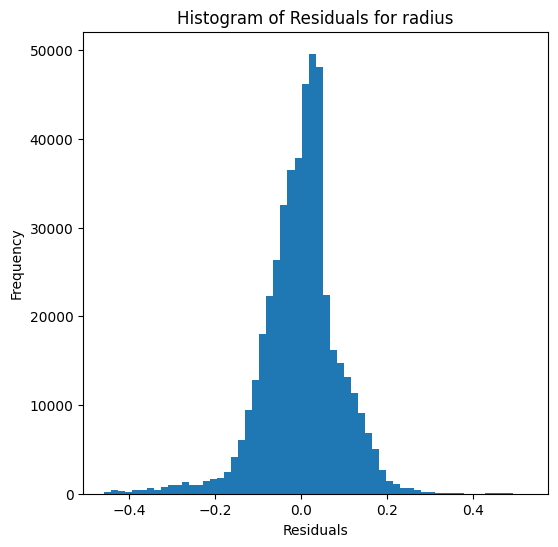

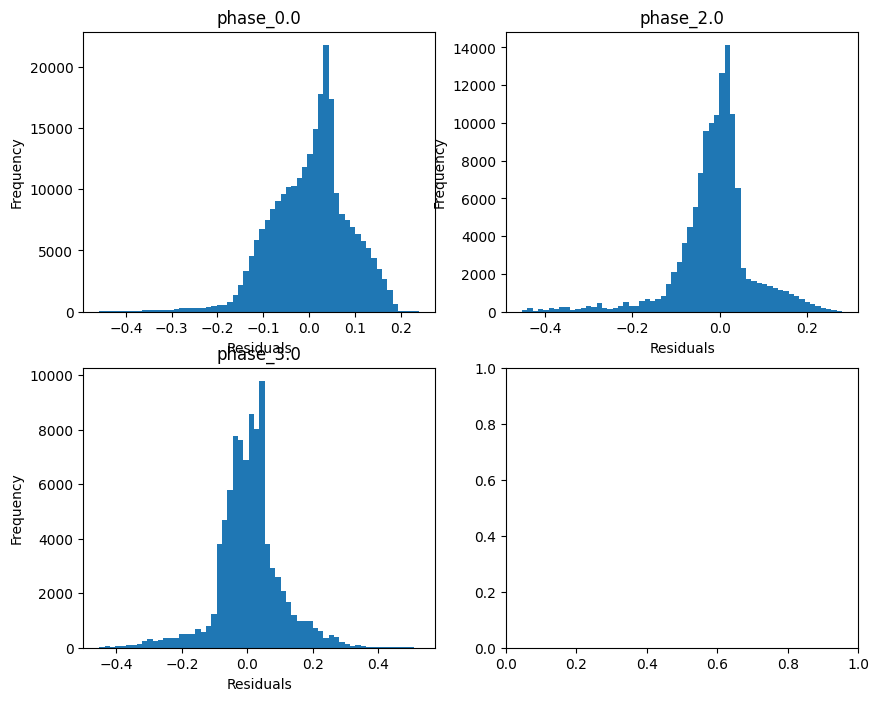

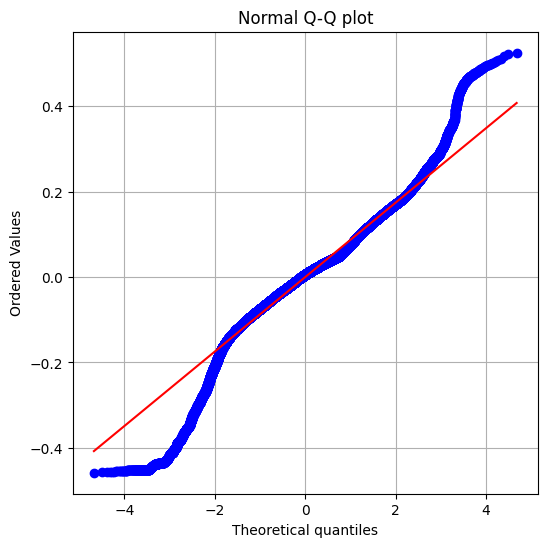

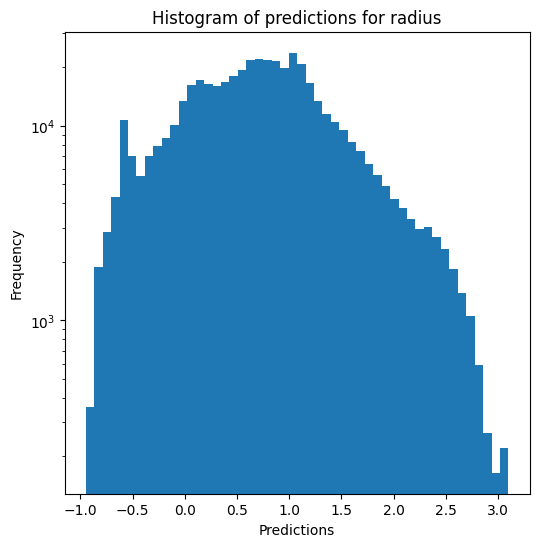

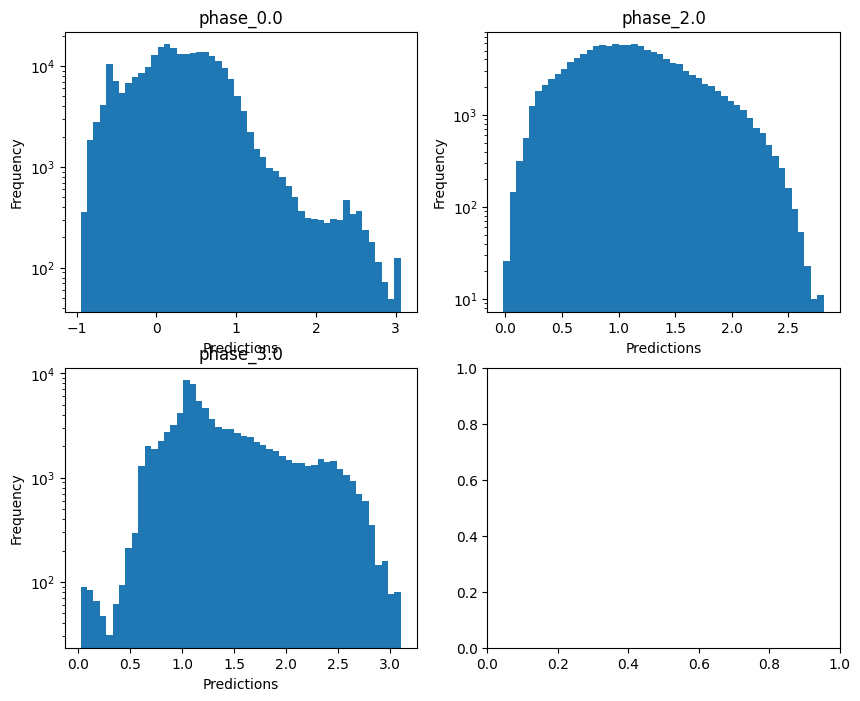

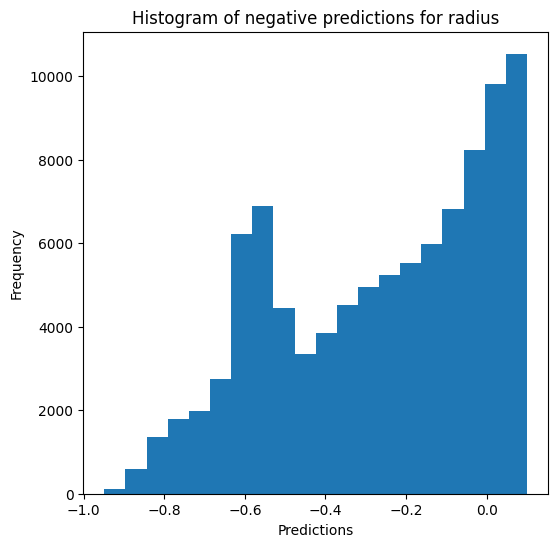

Saving results...


In [10]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show) #, override=False, use_preds=True

### Decision tree

In [11]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9936340302001091
  RMSE :  2.098472103763538
  MAE :  0.27008931723711926
  MedAE :  0.00593685565702623
  CORR :  0.9968269721840094
  MAX_ER :  131.77529017024463
  Percentiles : 
    75th percentile :  0.03085906559757101
    90th percentile :  0.18594781870295704
    95th percentile :  0.6745280714002232
    99th percentile :  5.948455329525592

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9992828062113351
  RMSE :  0.7952491953575107
  MAE :  0.06045397462604259
  MedAE :  0.0003546655033122015
  CORR :  0.9996414671007774
  MAX_ER :  105.8610741611694
  Percentiles : 
    75th percentile :  0.005490548158928021
    90th percentile :  0.025511775569056996
    95th percentile :  0.045460173907441156
    99th percentile :  0.75463855663929

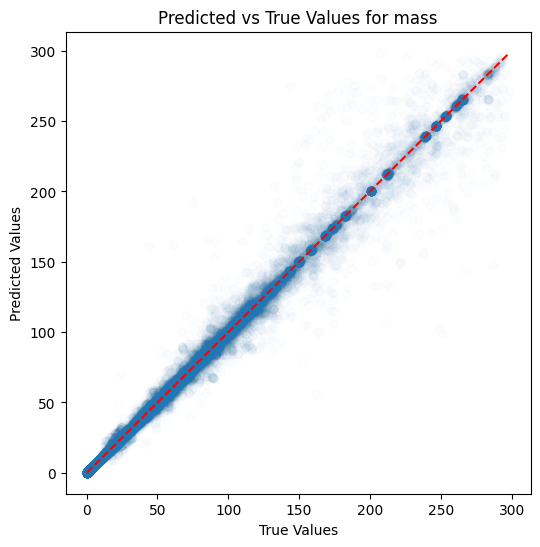

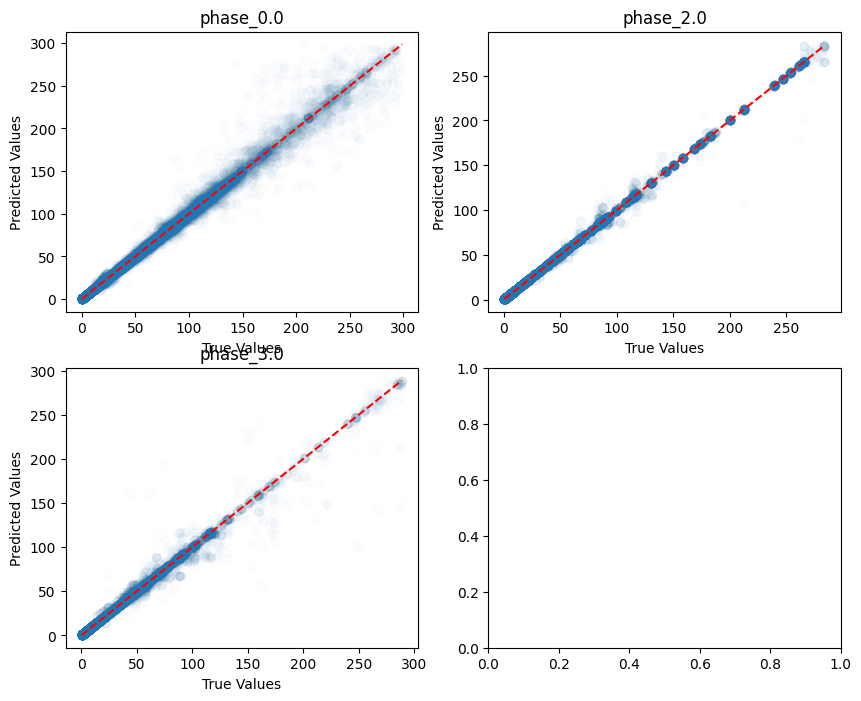

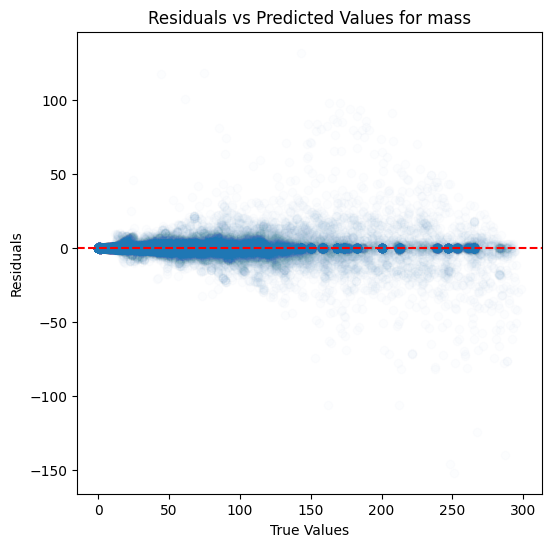

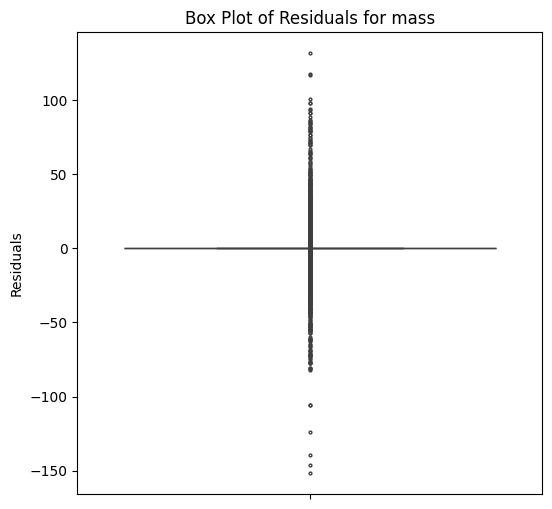

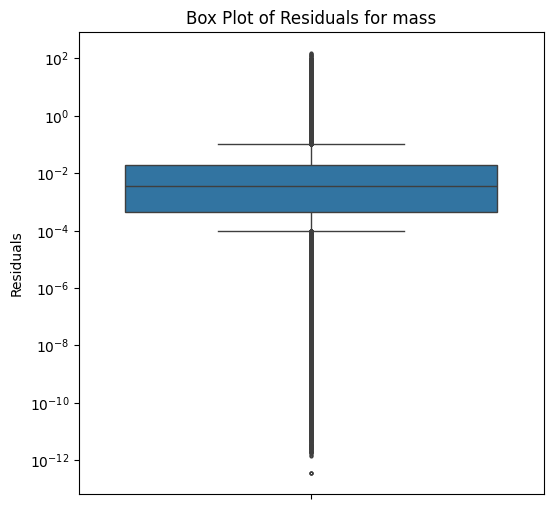

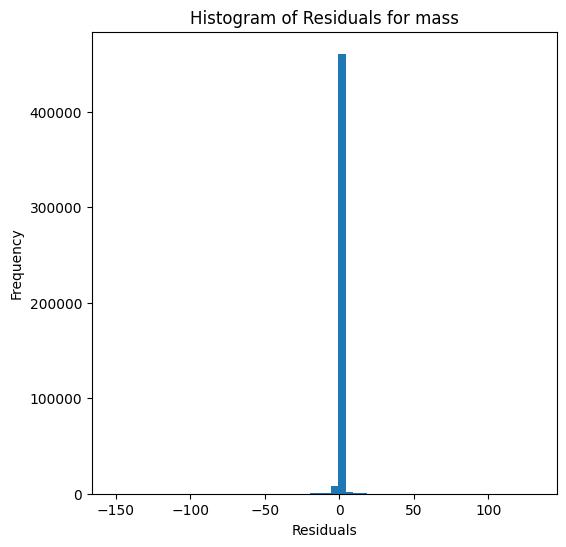

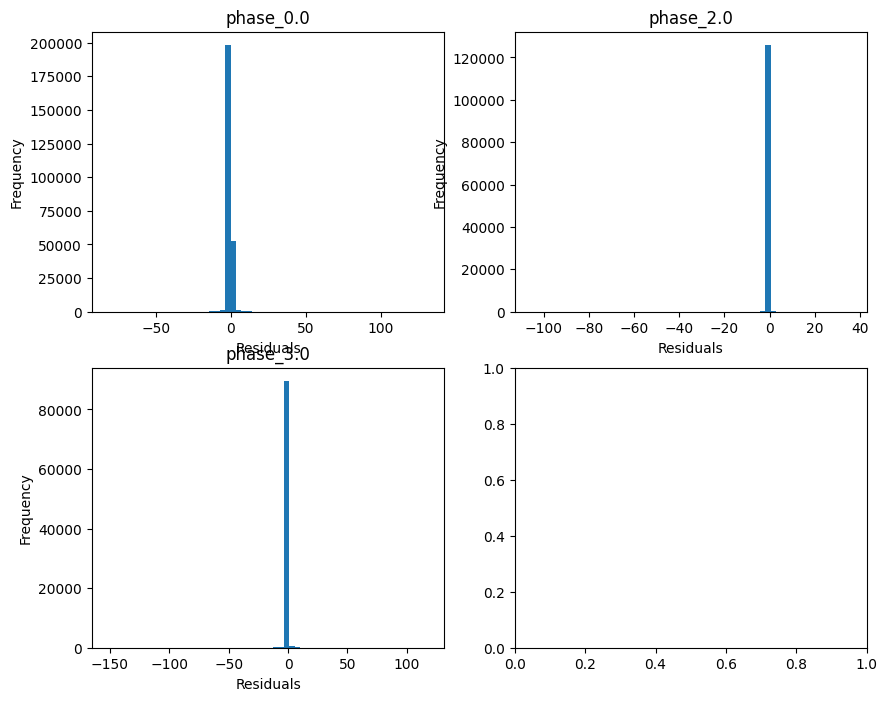

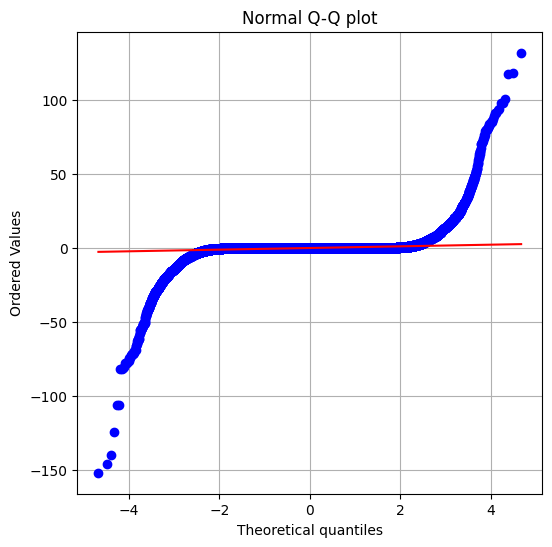

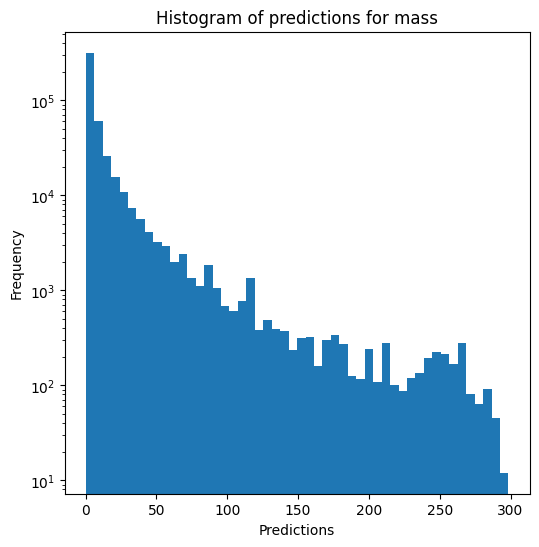

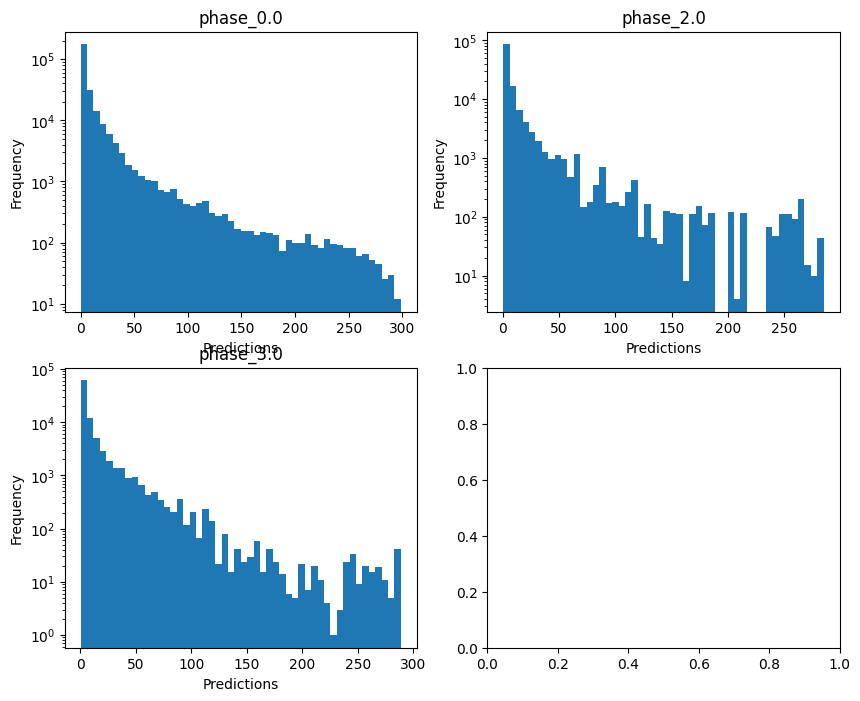

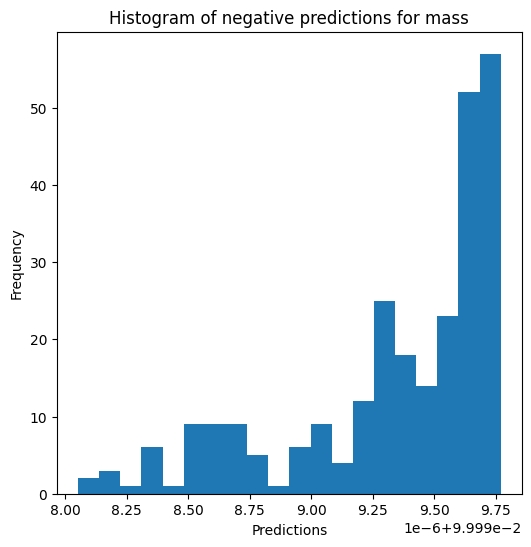


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9997790154053315
  RMSE :  0.008478470382287995
  MAE :  0.004607574205605183
  MedAE :  0.0026219881742016726
  CORR :  0.9998895445736318
  MAX_ER :  0.4783497157713891
  Percentiles : 
    75th percentile :  0.005336176343716192
    90th percentile :  0.010277698257346035
    95th percentile :  0.015192770390061833
    99th percentile :  0.03251042376033092

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9996013815341348
  RMSE :  0.00980443120633396
  MAE :  0.006734262658642821
  MedAE :  0.005217077332576092
  CORR :  0.9998018770327872
  MAX_ER :  0.18435517692909564
  Percentiles : 
    75th percentile :  0.00907696013021514
    90th percentile :  0.013451569582094657
    95th percentile :  0.016585706659864252
    99th percentile :  0.031504518154503044

radius results for t

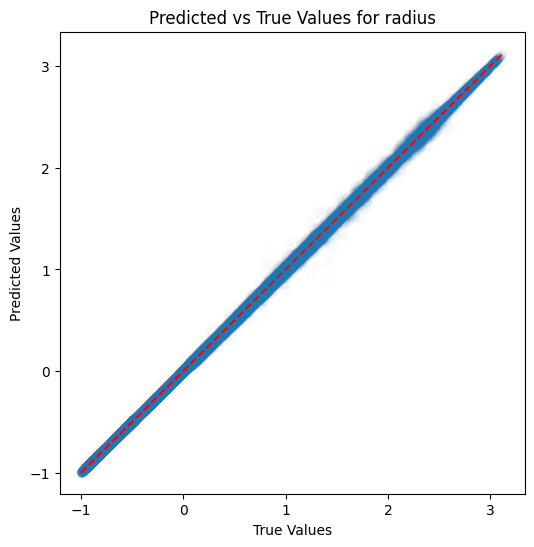

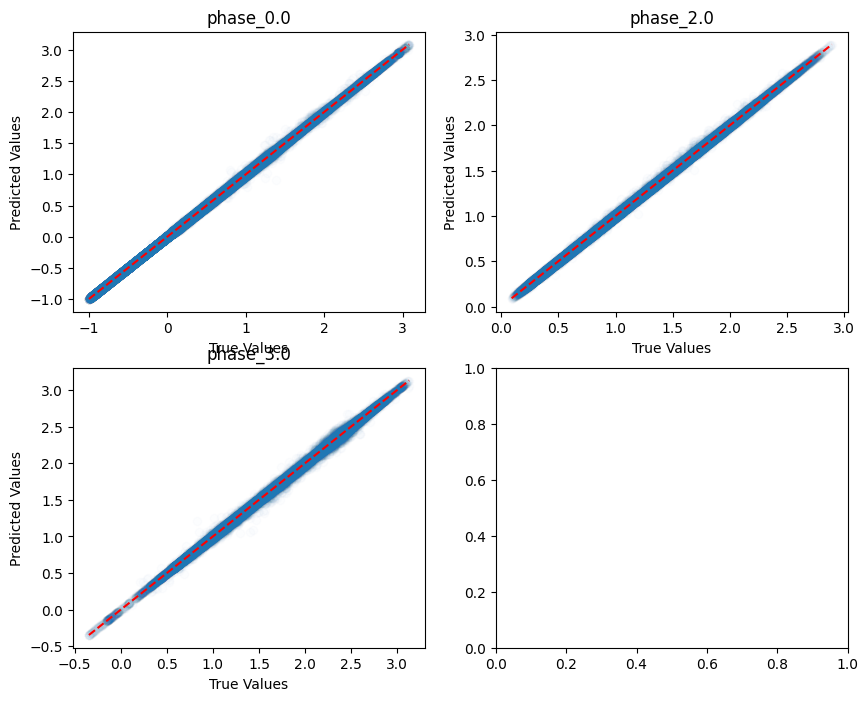

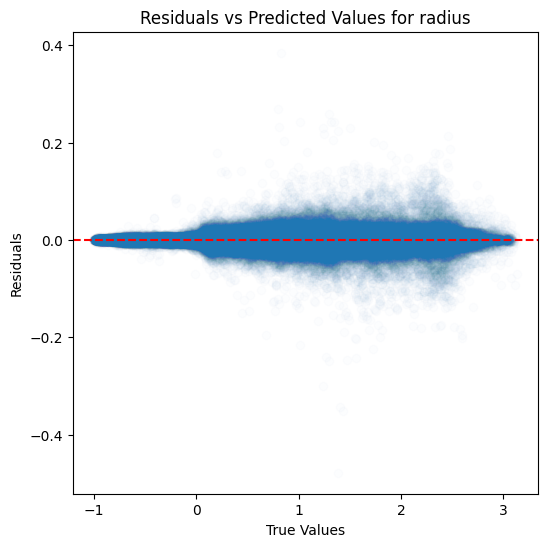

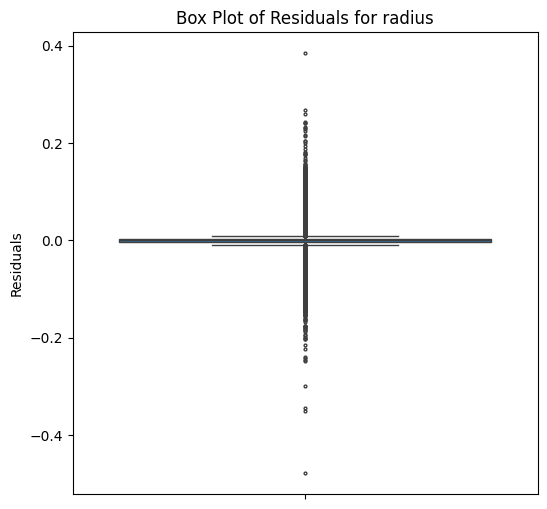

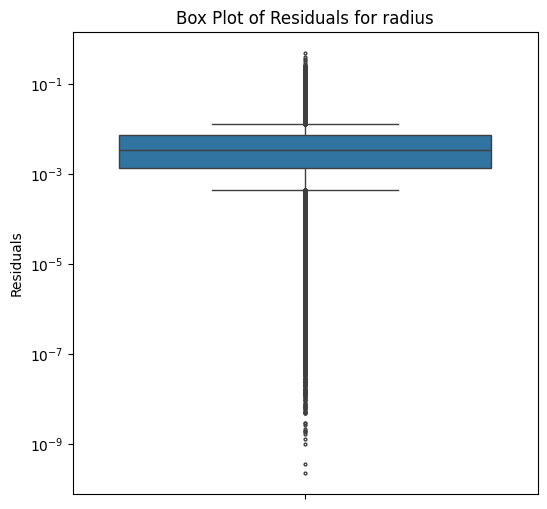

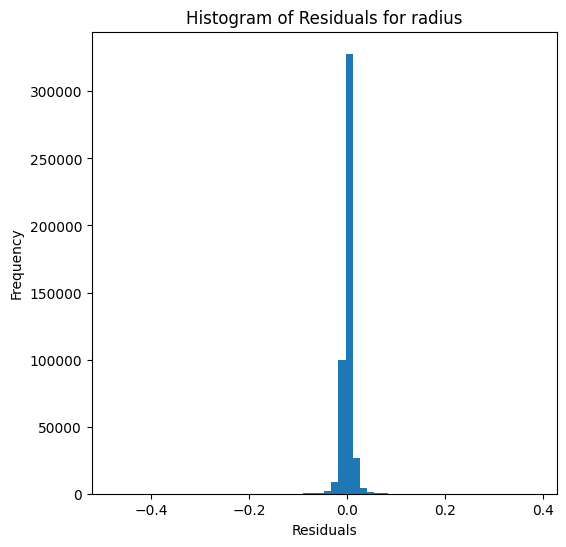

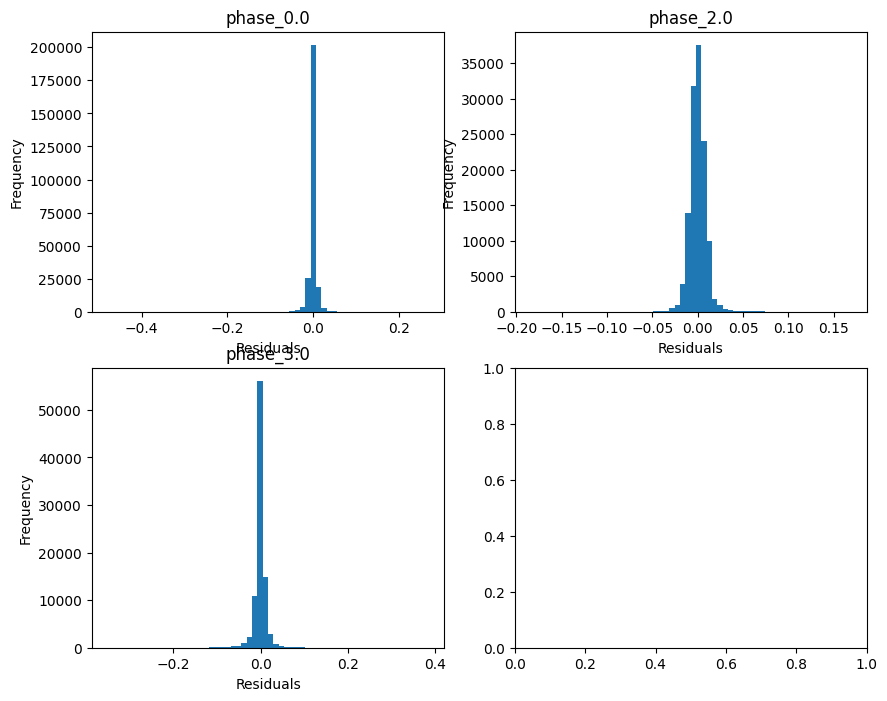

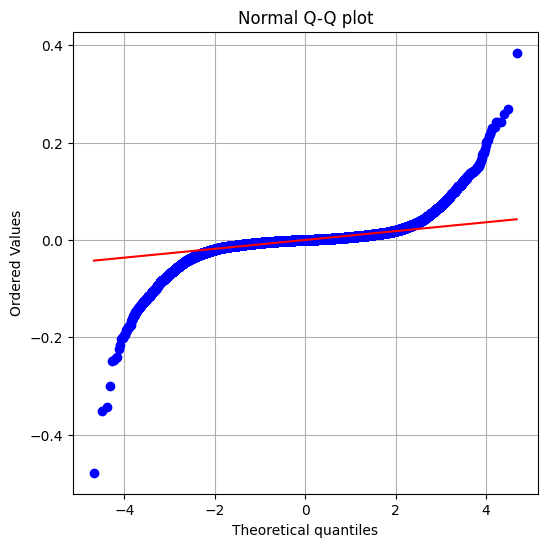

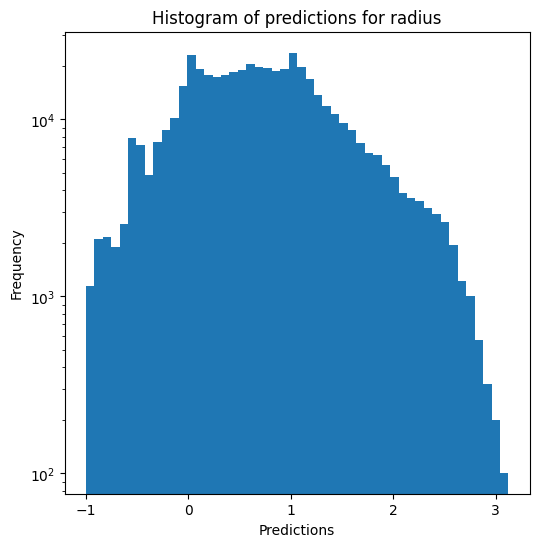

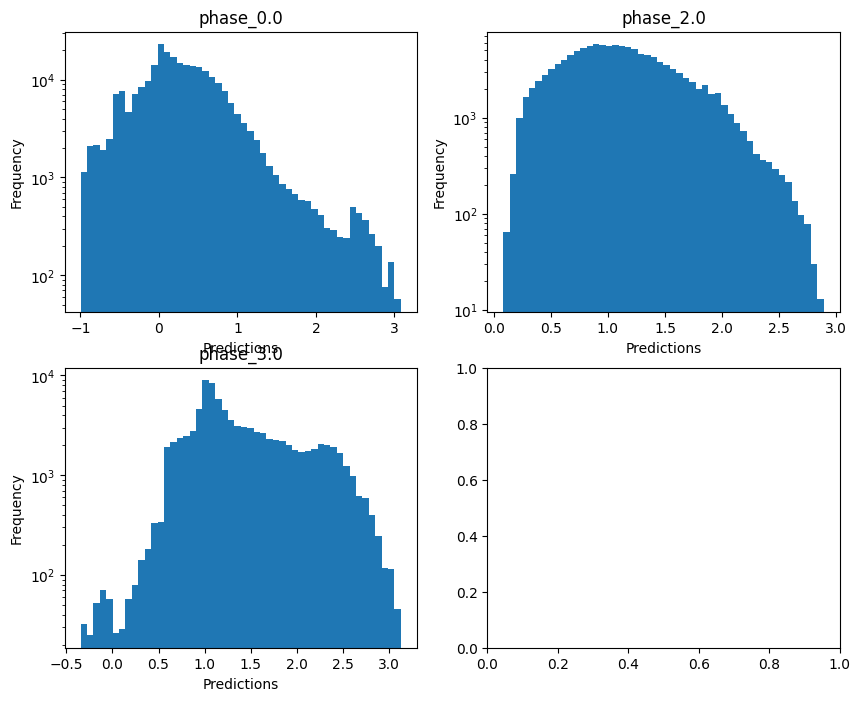

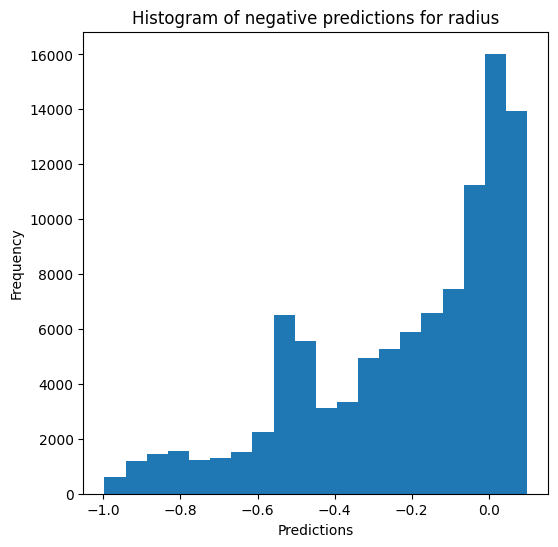

Saving results...


In [12]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show)

### K-nearest neighbours

In [13]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9843387655163102
  RMSE :  3.292362185047644
  MAE :  0.4317822333077811
  MedAE :  0.010309898110725357
  CORR :  0.9924111983284241
  MAX_ER :  126.67441415982648
  Percentiles : 
    75th percentile :  0.05187255440003935
    90th percentile :  0.33456343769282815
    95th percentile :  1.0302260826357286
    99th percentile :  8.942648085934486

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9993836364150782
  RMSE :  0.7372507757129543
  MAE :  0.09538418274204148
  MedAE :  0.003644066674525215
  CORR :  0.9996927065174758
  MAX_ER :  37.48661252169403
  Percentiles : 
    75th percentile :  0.01708344572699827
    90th percentile :  0.07857928736632087
    95th percentile :  0.1618304217730987
    99th percentile :  2.

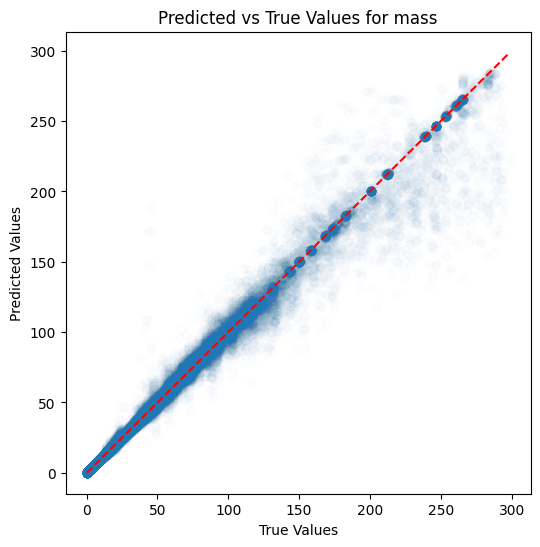

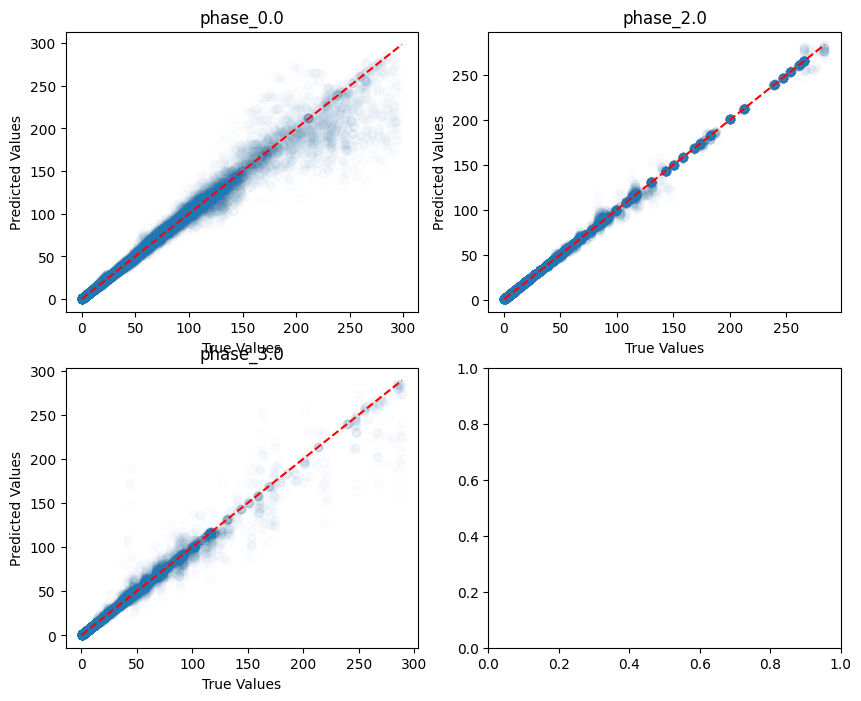

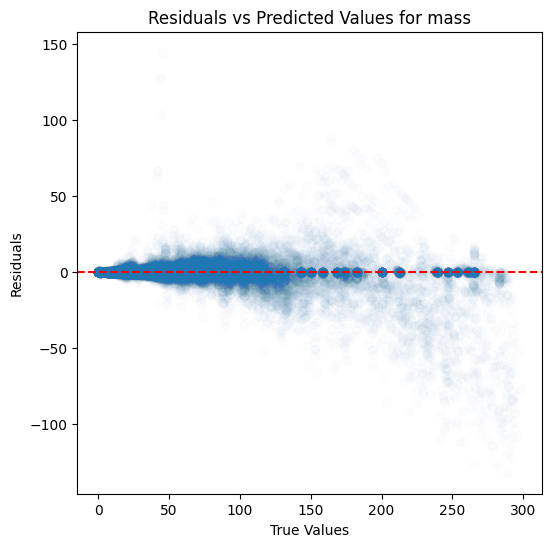

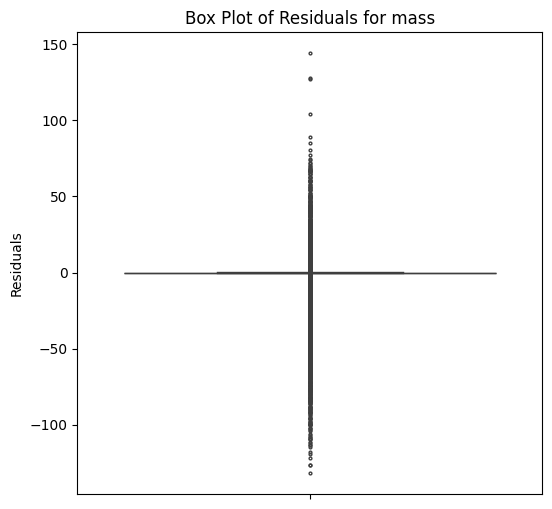

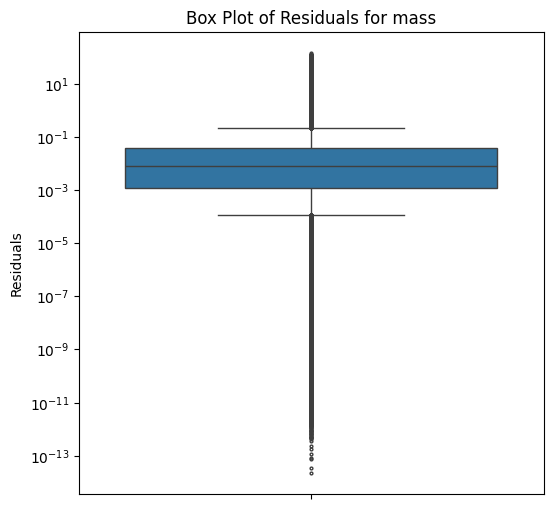

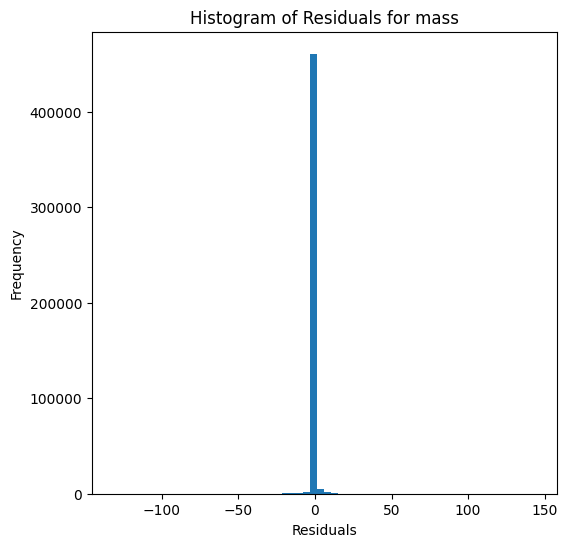

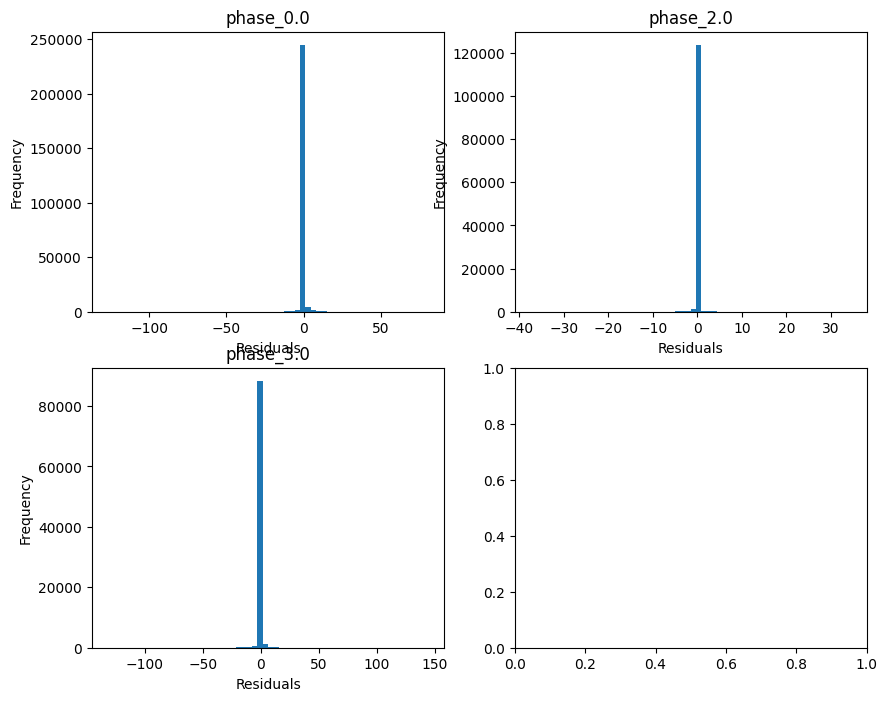

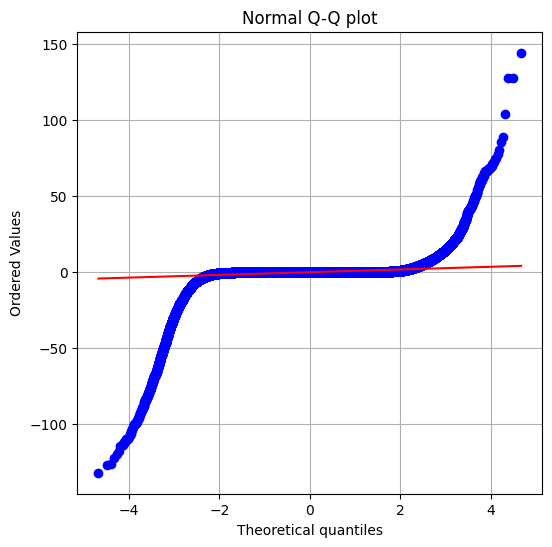

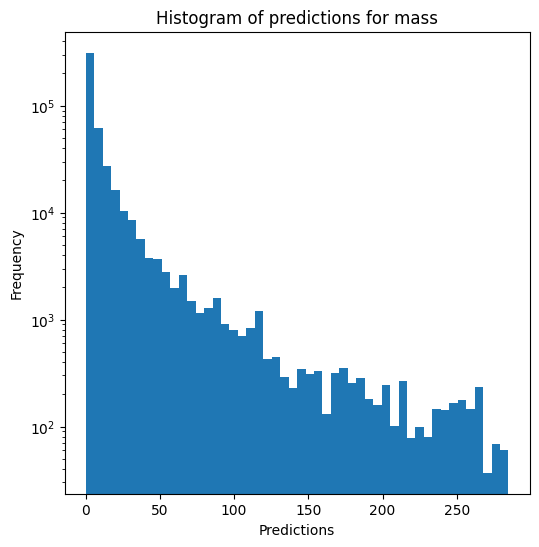

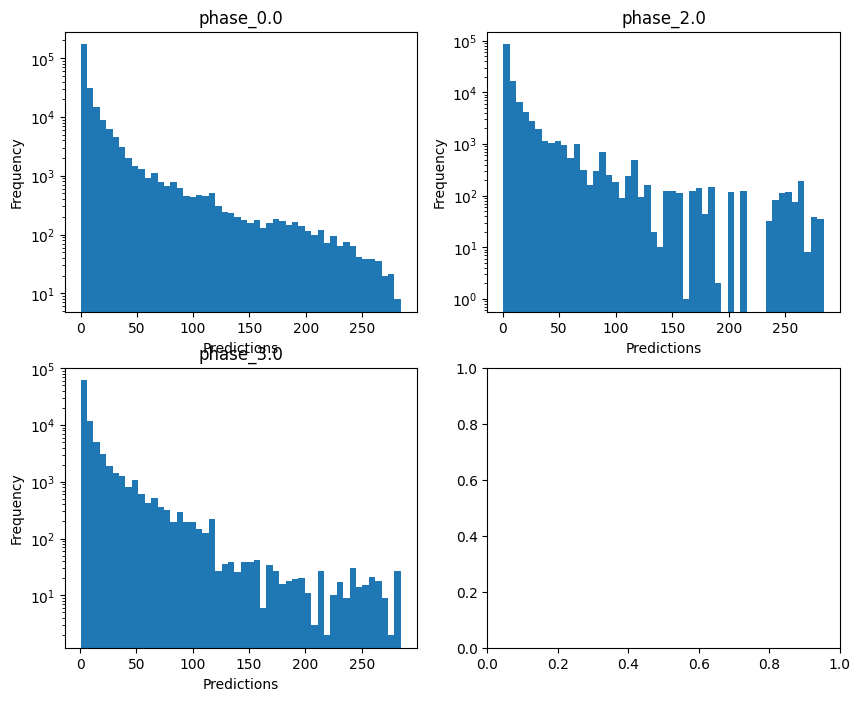


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9998333563537635
  RMSE :  0.007362583562507818
  MAE :  0.004268976716445437
  MedAE :  0.002587315638011012
  CORR :  0.9999169942116342
  MAX_ER :  0.1541932825054977
  Percentiles : 
    75th percentile :  0.00518315713484023
    90th percentile :  0.009551796207118502
    95th percentile :  0.013550120941980666
    99th percentile :  0.02639653929001715

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9999055166815642
  RMSE :  0.004771005490760497
  MAE :  0.0034537346530787026
  MedAE :  0.0025434069250853675
  CORR :  0.9999527572442021
  MAX_ER :  0.07723242145030396
  Percentiles : 
    75th percentile :  0.004691856845975062
    90th percentile :  0.0077227474516430306
    95th percentile :  0.009780350181265789
    99th percentile :  0.014525614812519533

radius results fo

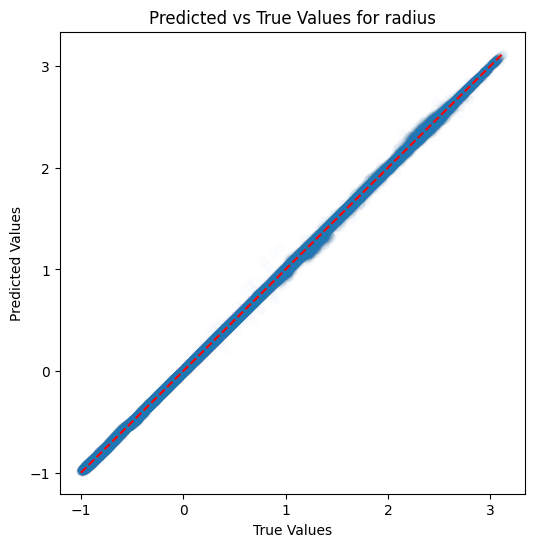

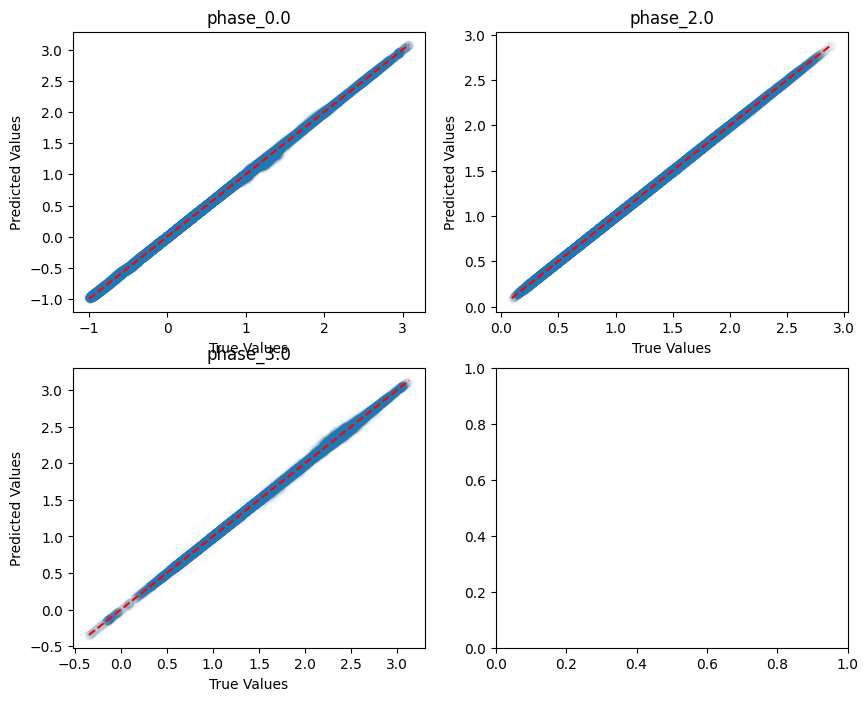

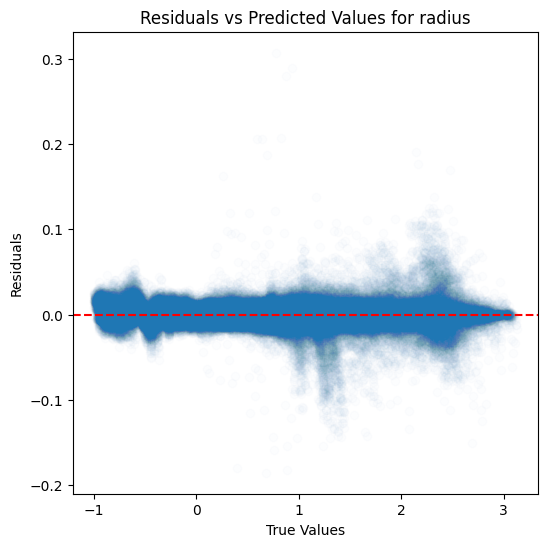

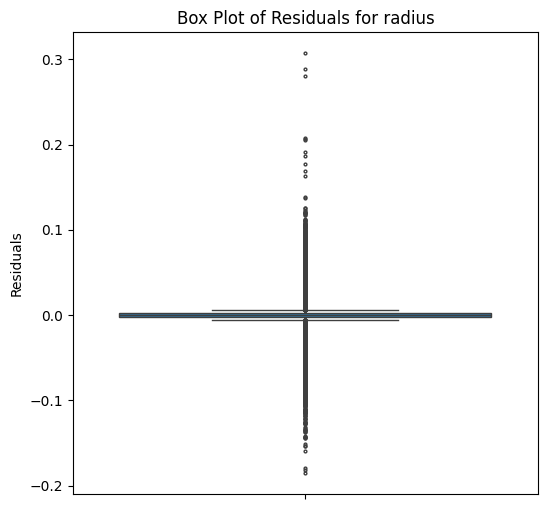

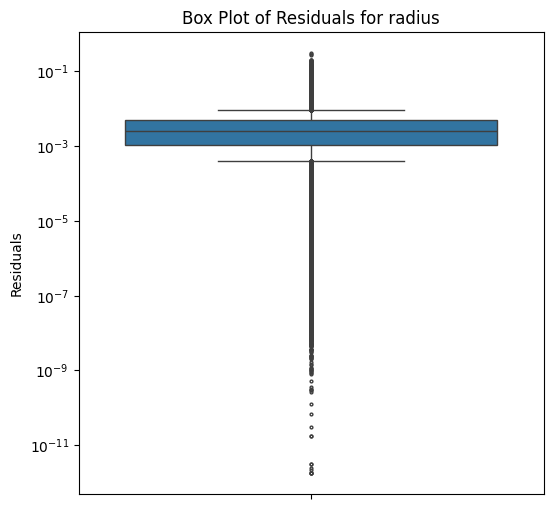

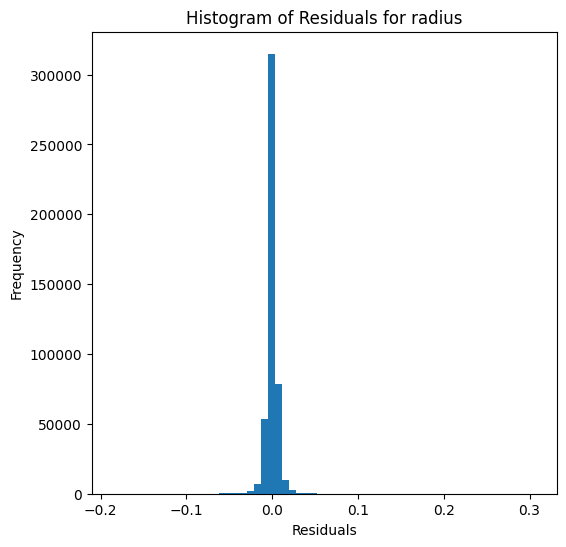

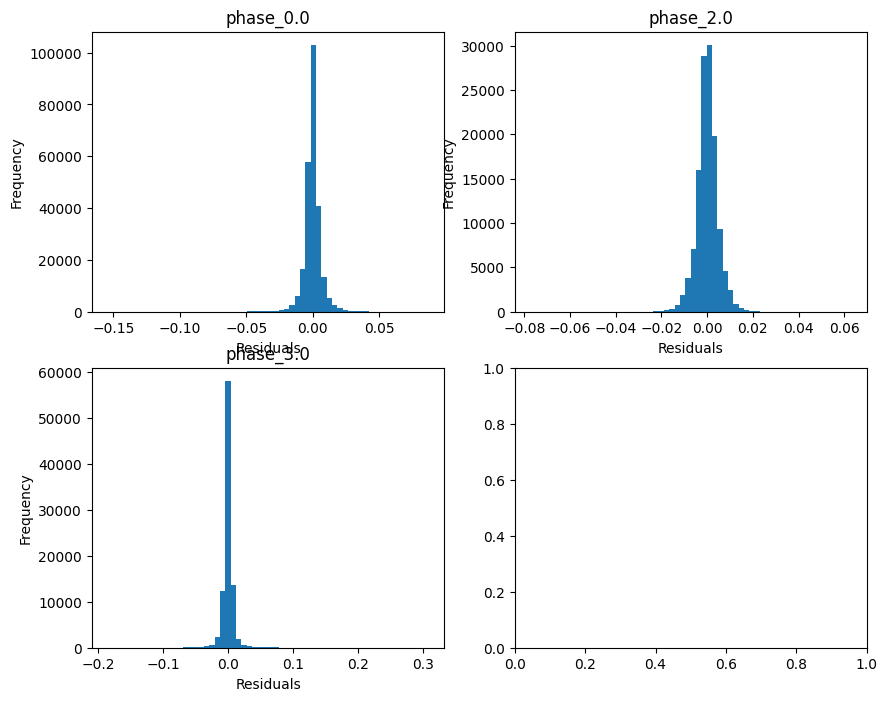

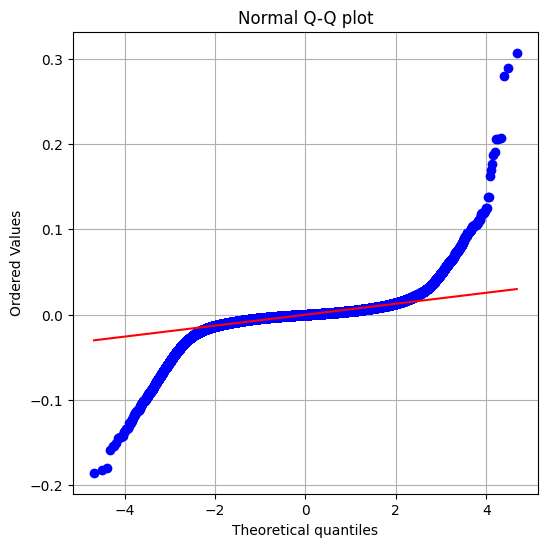

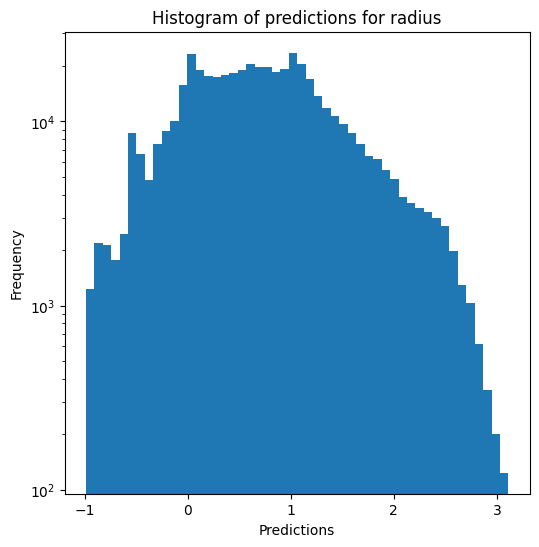

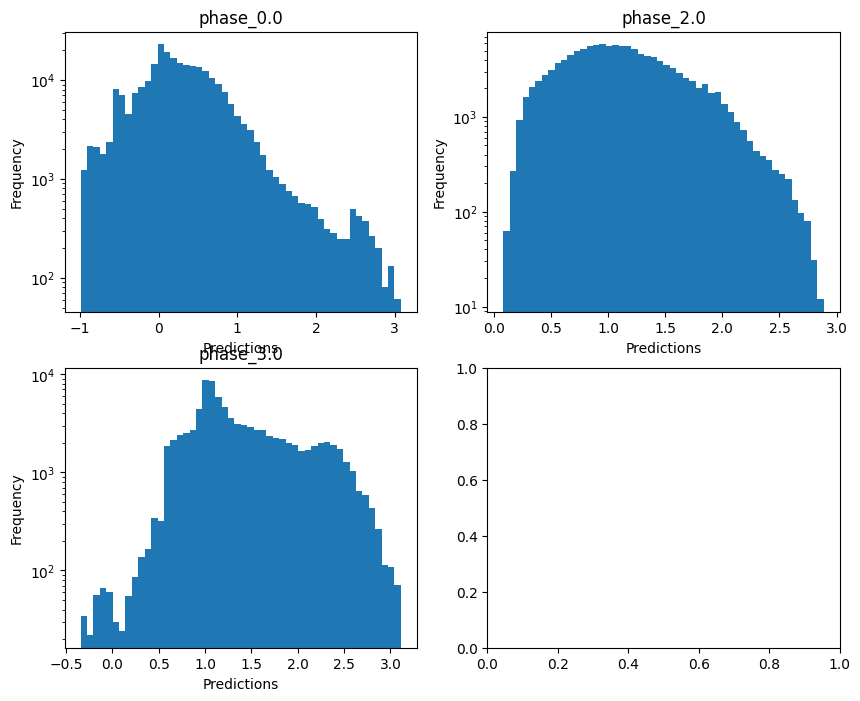

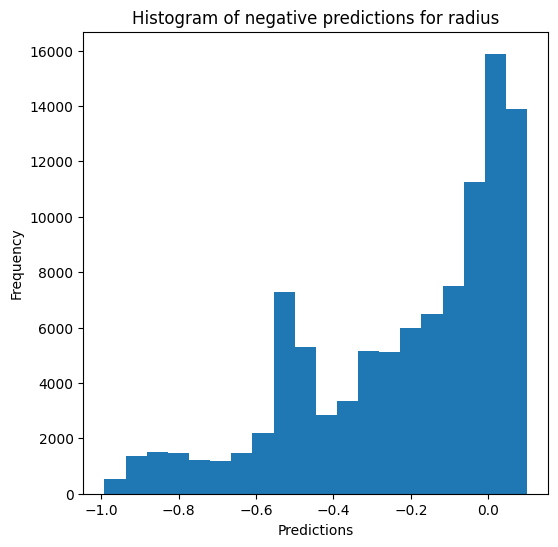

Saving results...


In [14]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show)

### Random forests

In [15]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9973661987481759
  RMSE :  1.349981081228535
  MAE :  0.16767754891327383
  MedAE :  0.0035332021808852643
  CORR :  0.9986840004415223
  MAX_ER :  83.53771688684816
  Percentiles : 
    75th percentile :  0.016281549193272182
    90th percentile :  0.10797519225601147
    95th percentile :  0.4157307430383175
    99th percentile :  3.6031597930670283

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9997496322236138
  RMSE :  0.4698973478758848
  MAE :  0.058992993851356076
  MedAE :  0.0040515693376192985
  CORR :  0.9998754804643019
  MAX_ER :  22.98109231545297
  Percentiles : 
    75th percentile :  0.010592640156522504
    90th percentile :  0.025544217877082744
    95th percentile :  0.07294744116899539
    99th percentile :  1.35850359403

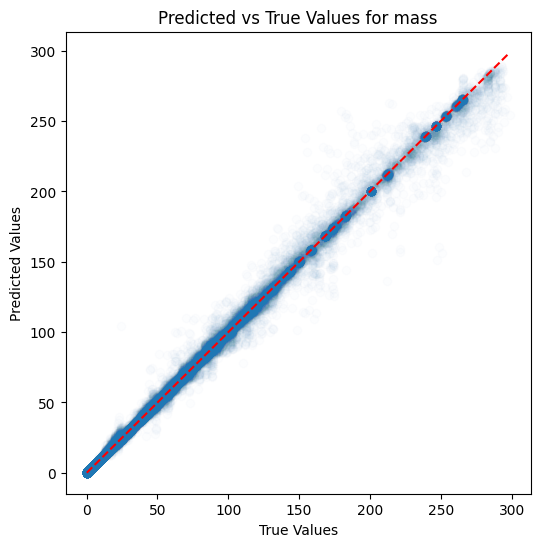

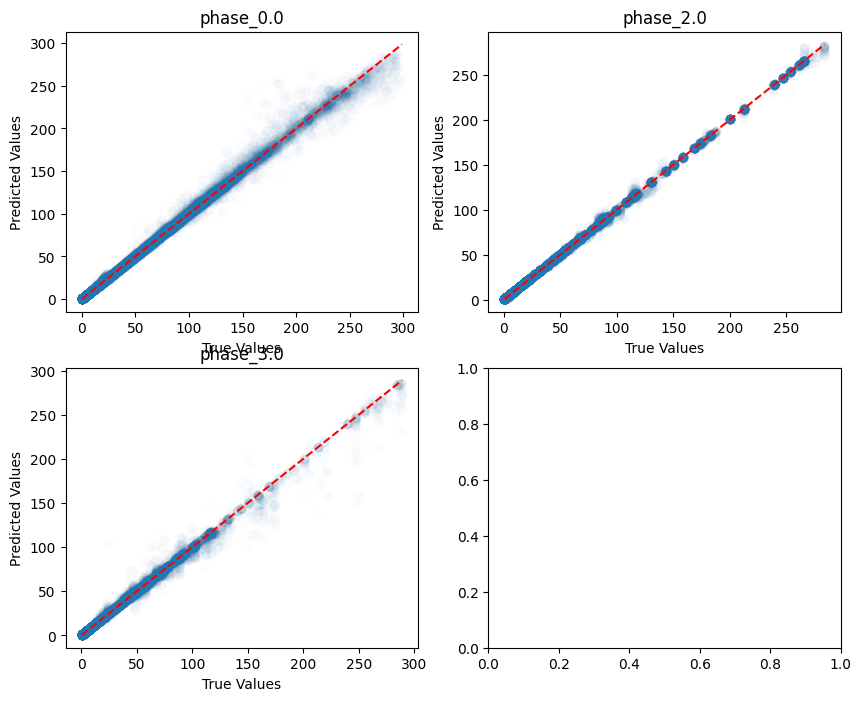

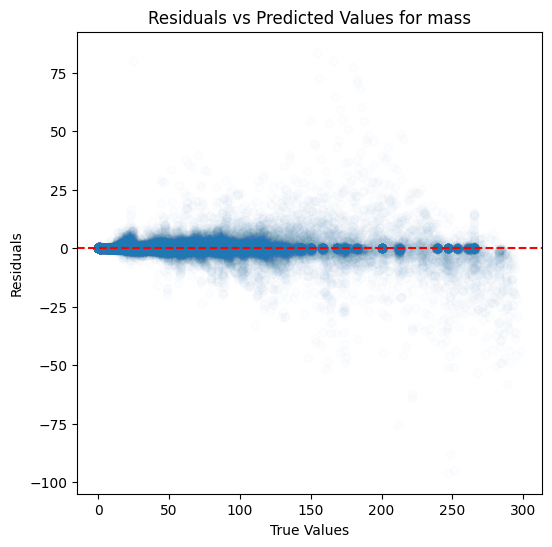

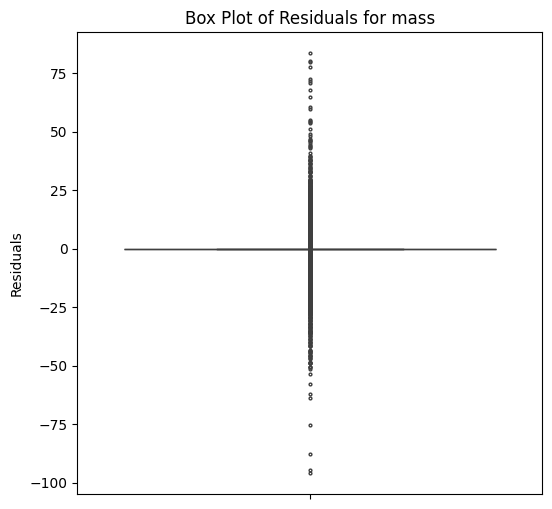

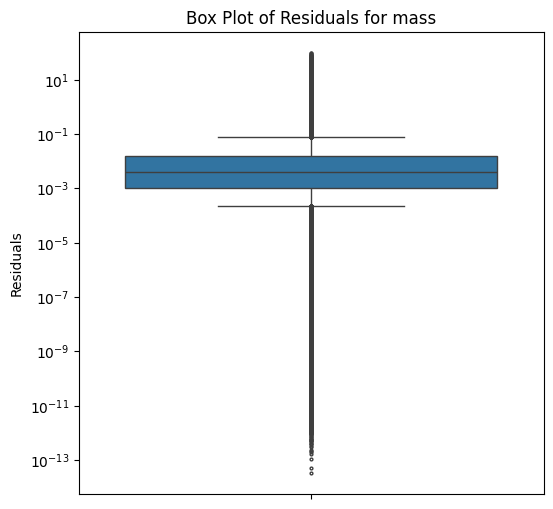

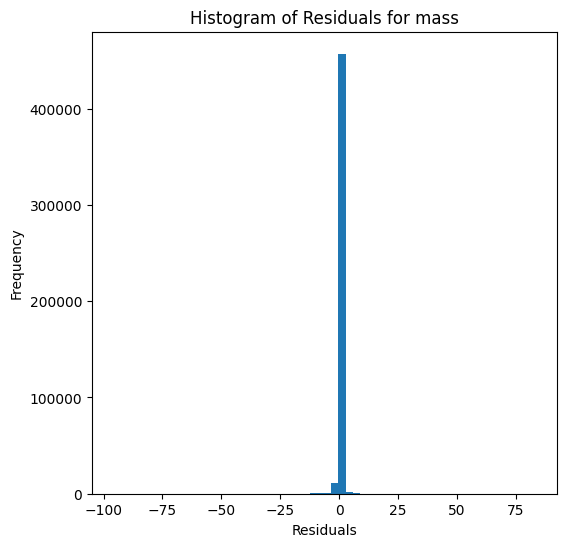

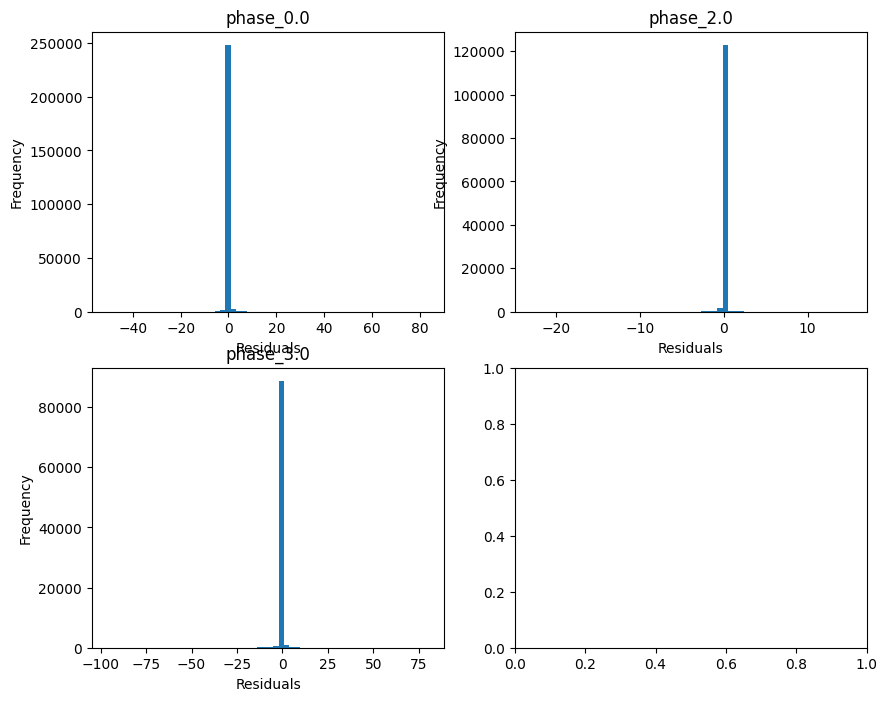

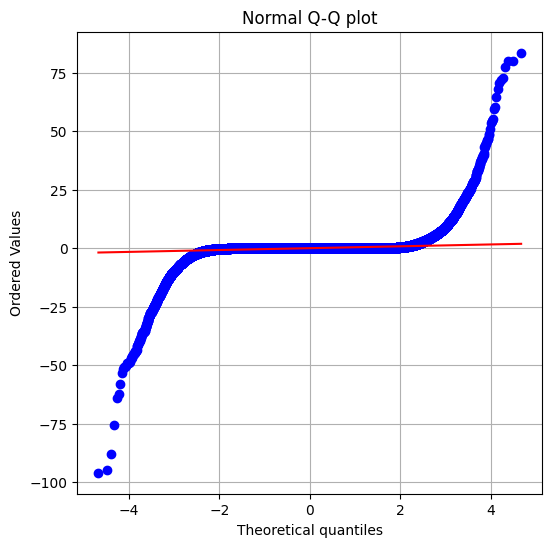

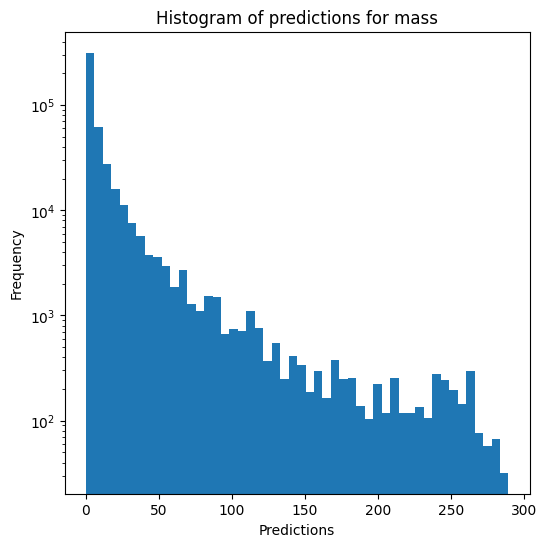

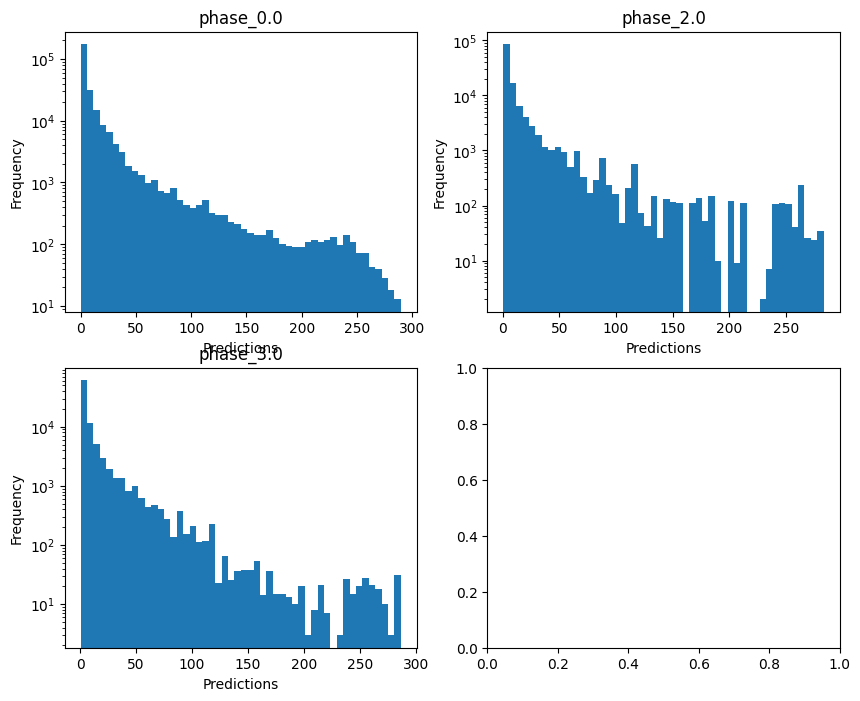

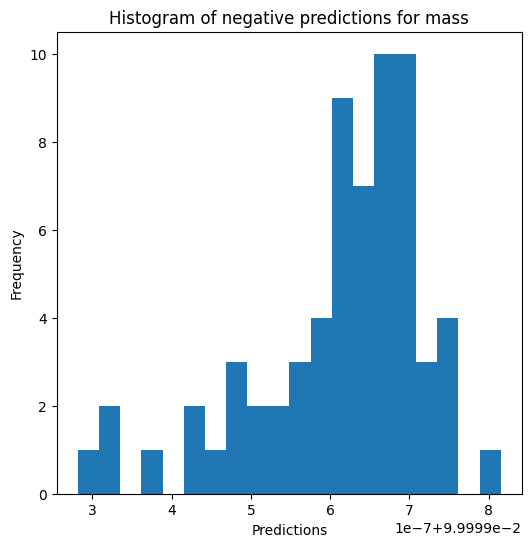


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9999465508573717
  RMSE :  0.004169504760403235
  MAE :  0.00208281725507701
  MedAE :  0.0010142789244010735
  CORR :  0.9999733173582267
  MAX_ER :  0.35804468052808747
  Percentiles : 
    75th percentile :  0.0023219746419131833
    90th percentile :  0.004847603397530131
    95th percentile :  0.007497783054837046
    99th percentile :  0.016501064615537235

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9999326234217092
  RMSE :  0.004059224100979492
  MAE :  0.002686096107059847
  MedAE :  0.0017587641751823924
  CORR :  0.999966988493253
  MAX_ER :  0.09116993923868488
  Percentiles : 
    75th percentile :  0.003591811259430977
    90th percentile :  0.006174989627465877
    95th percentile :  0.008280516780824787
    99th percentile :  0.014061043469126707

radius results f

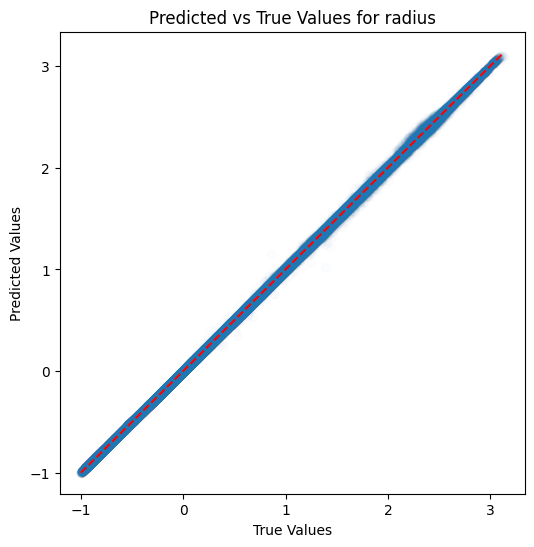

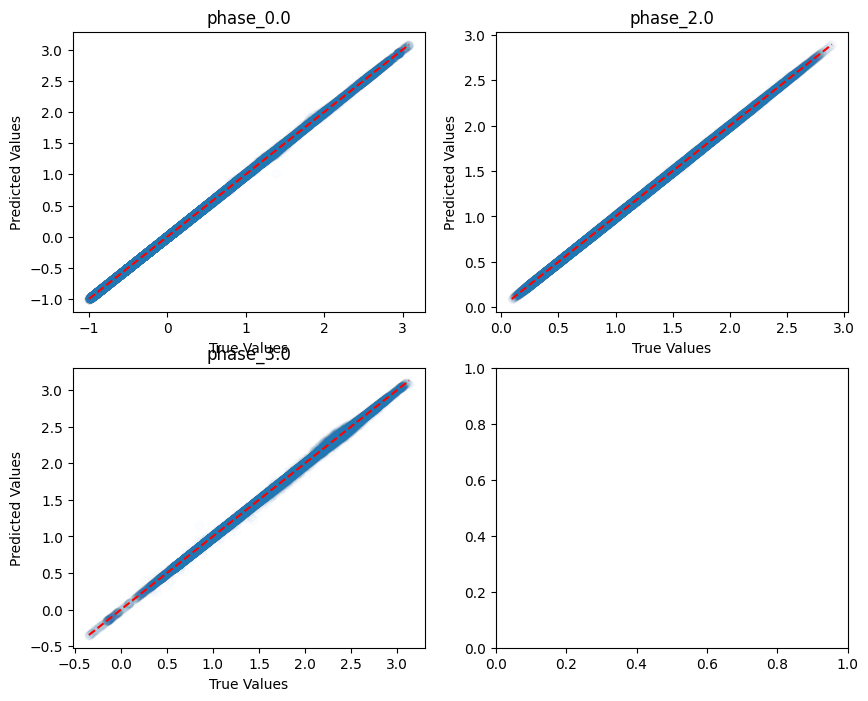

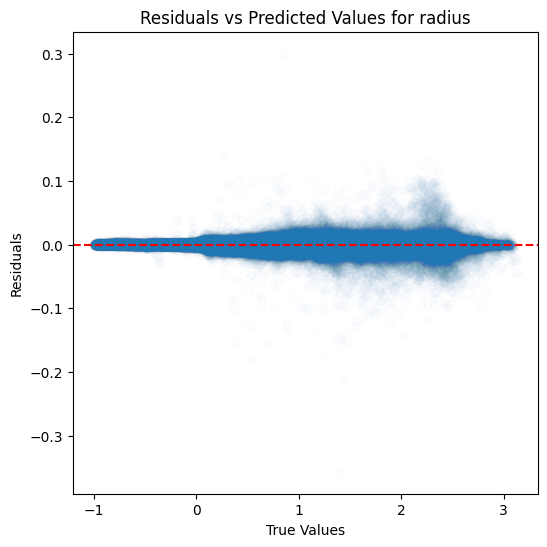

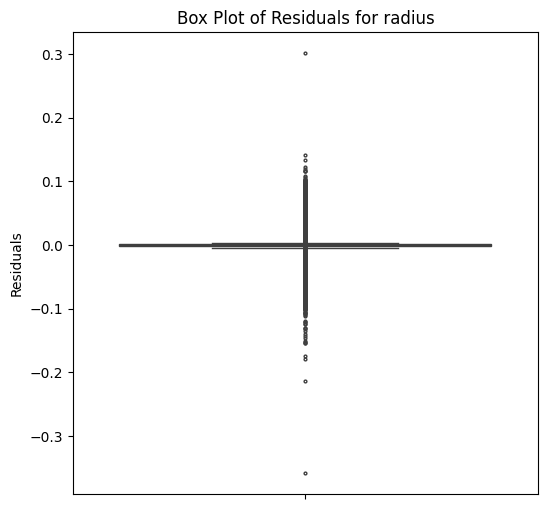

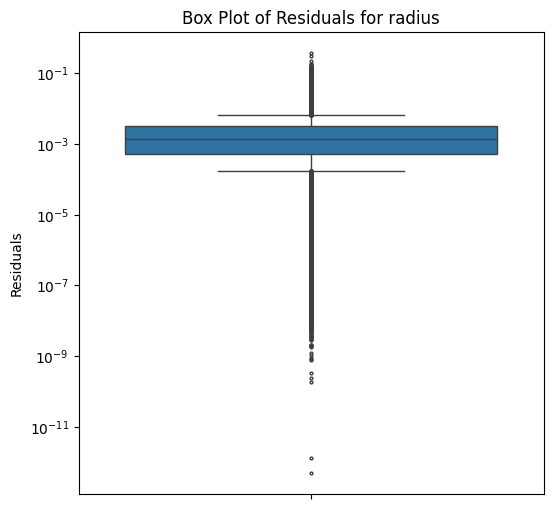

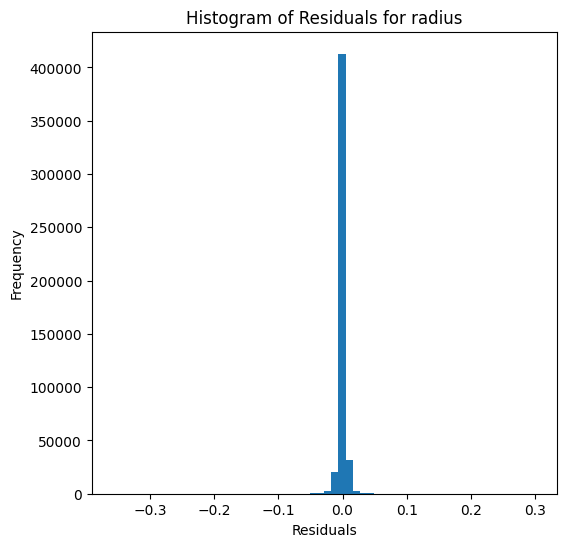

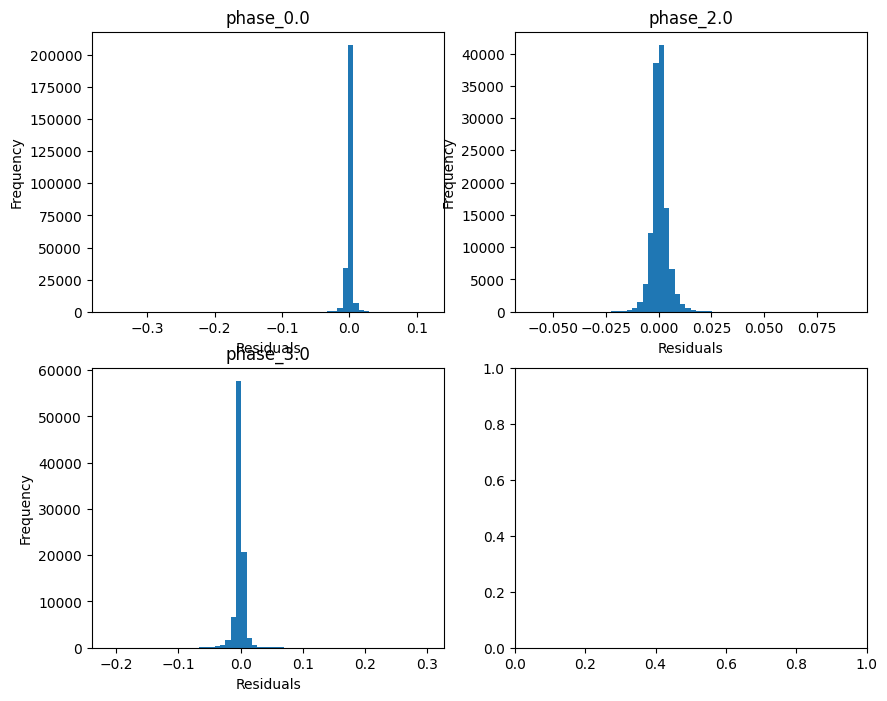

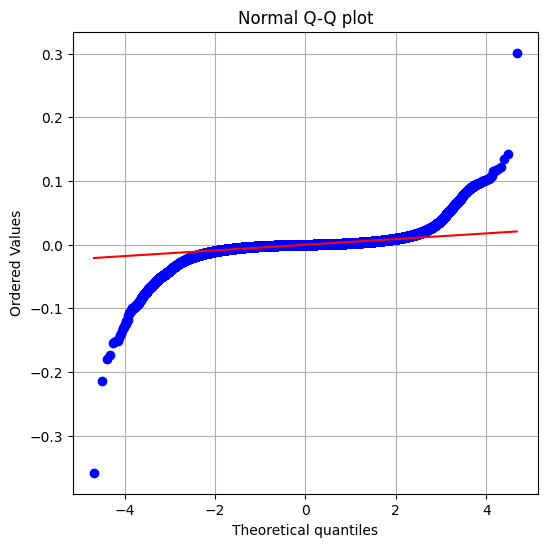

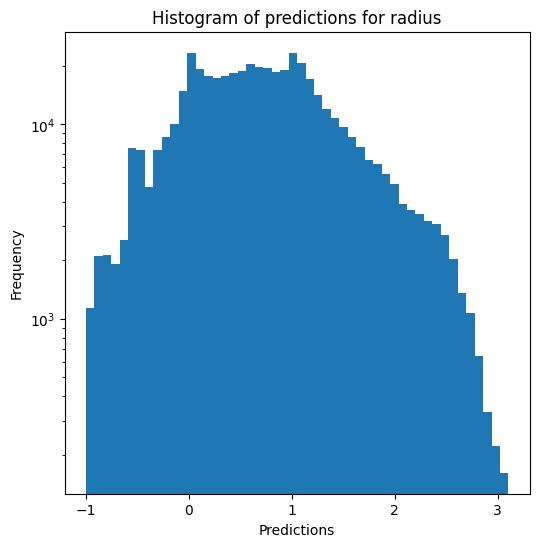

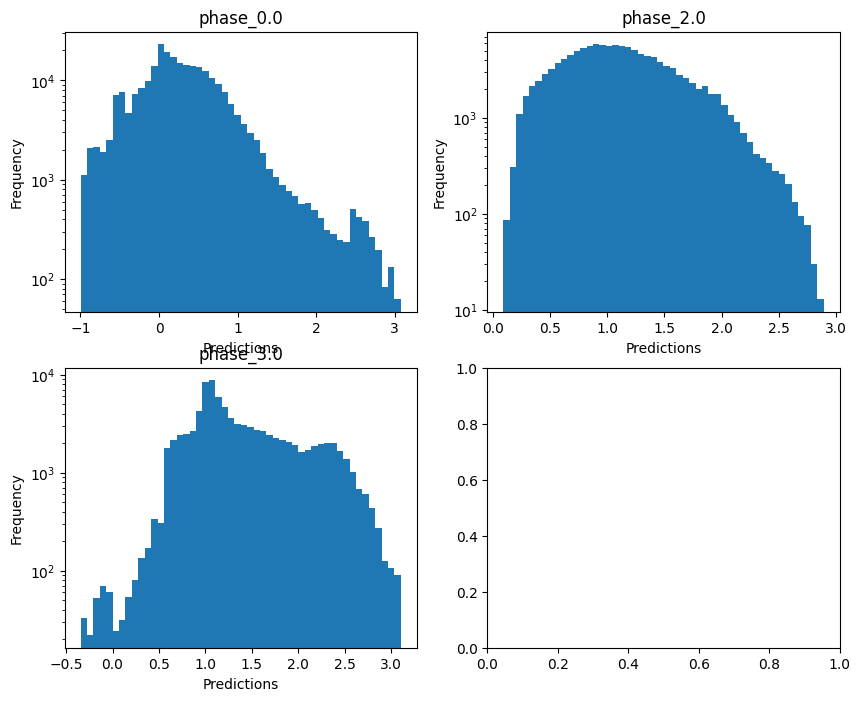

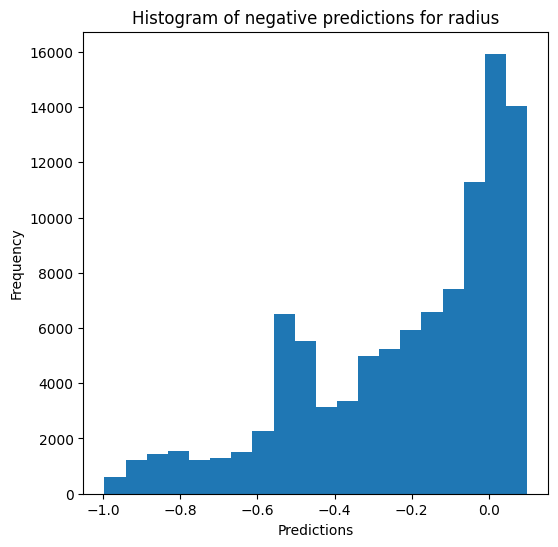

Saving results...


In [16]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)
# average depth de 44-46

### XGBoost

In [17]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9910072956179956
  RMSE :  2.494119573996689
  MAE :  0.6773915424575189
  MedAE :  0.12578609649357553
  CORR :  0.9955145412428942
  MAX_ER :  72.95365928611318
  Percentiles : 
    75th percentile :  0.3848369778327197
    90th percentile :  1.2895633422320578
    95th percentile :  2.6983724699299283
    99th percentile :  11.034491302904975

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9988754736593098
  RMSE :  0.9959317895204074
  MAE :  0.29336744162478817
  MedAE :  0.07123763131807914
  CORR :  0.9994709362034415
  MAX_ER :  39.12064222195215
  Percentiles : 
    75th percentile :  0.1562658213764383
    90th percentile :  0.5480041757942958
    95th percentile :  1.3215092460814832
    99th percentile :  4.414407992232011

mass res

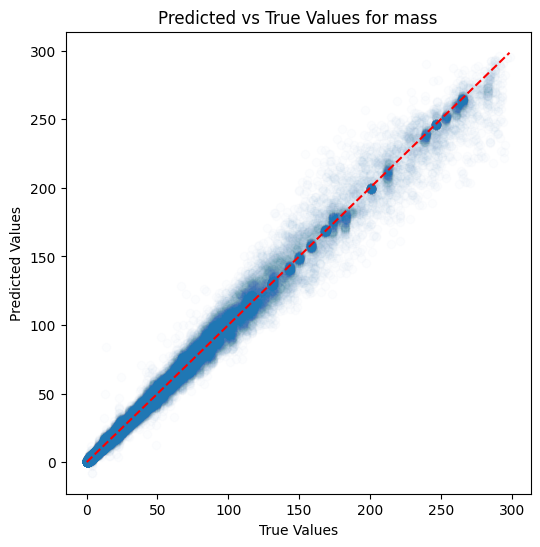

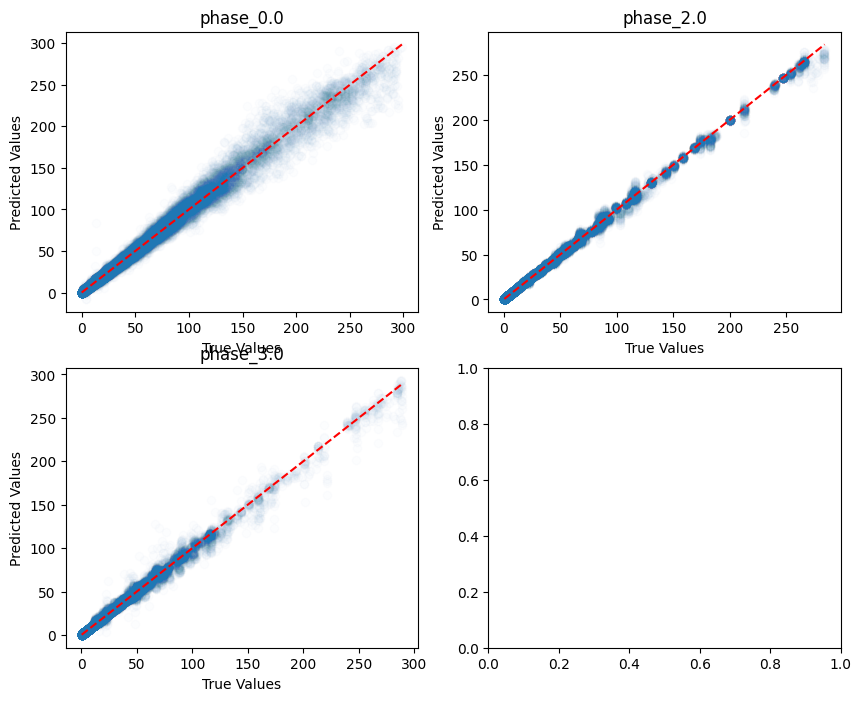

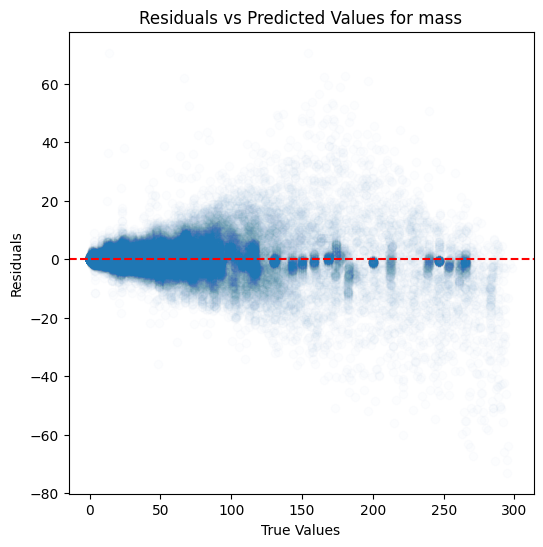

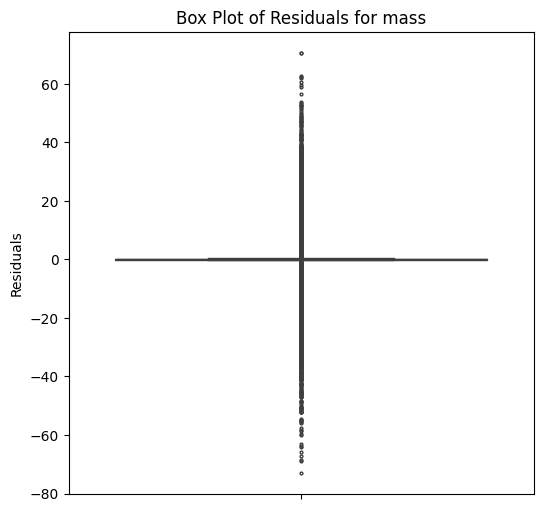

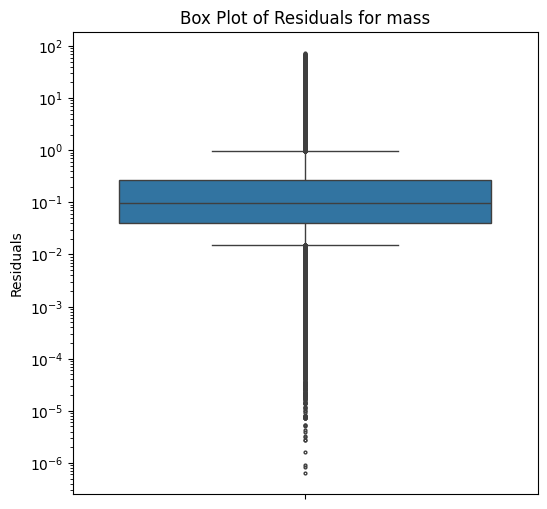

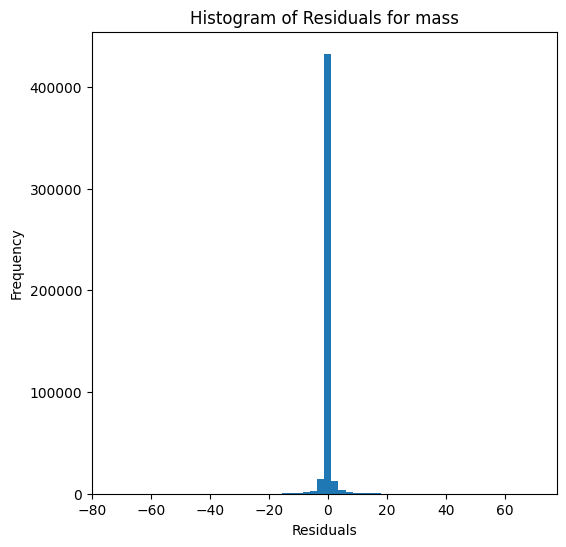

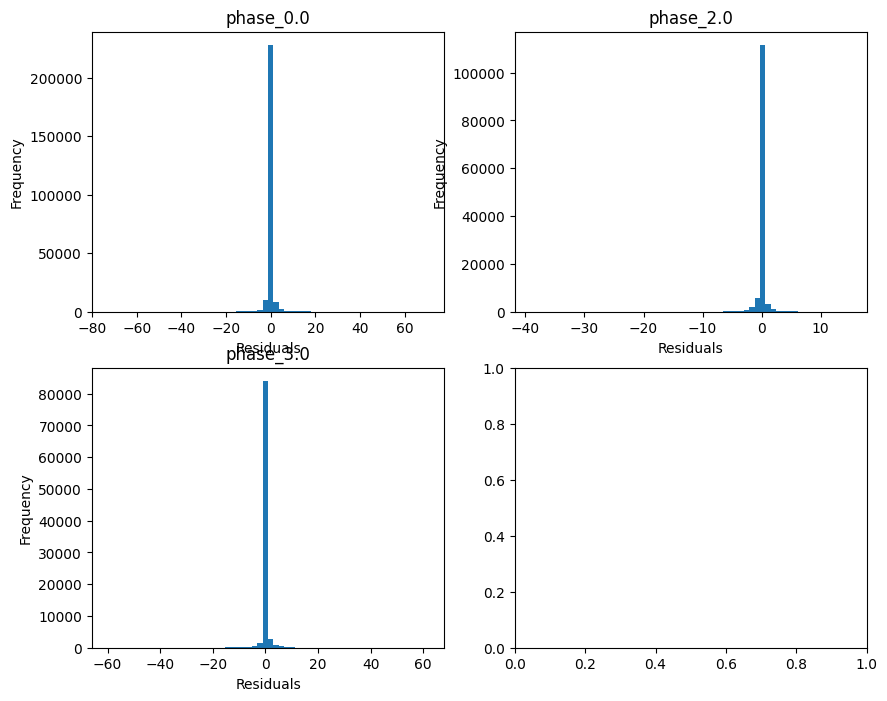

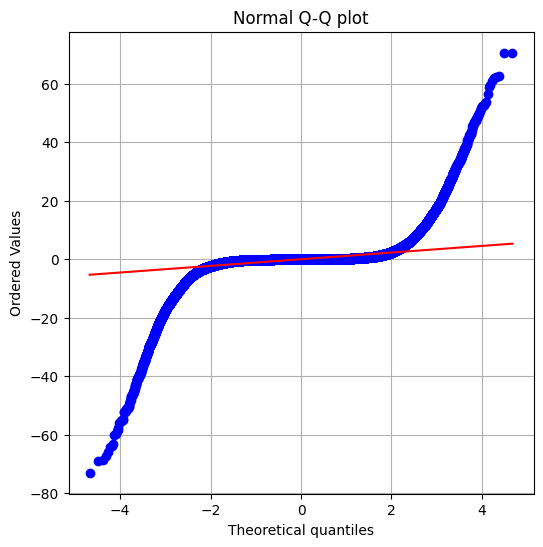

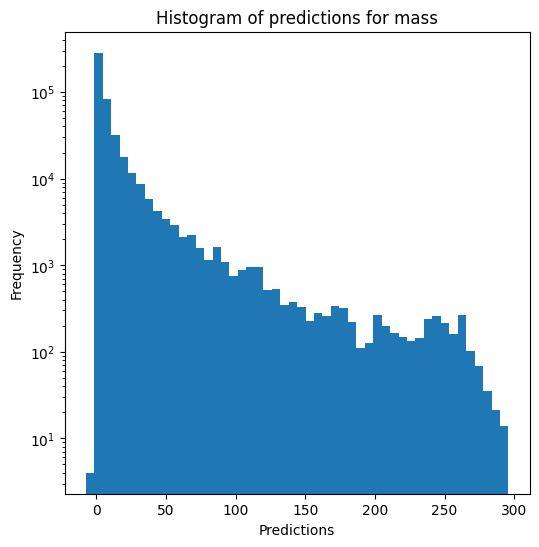

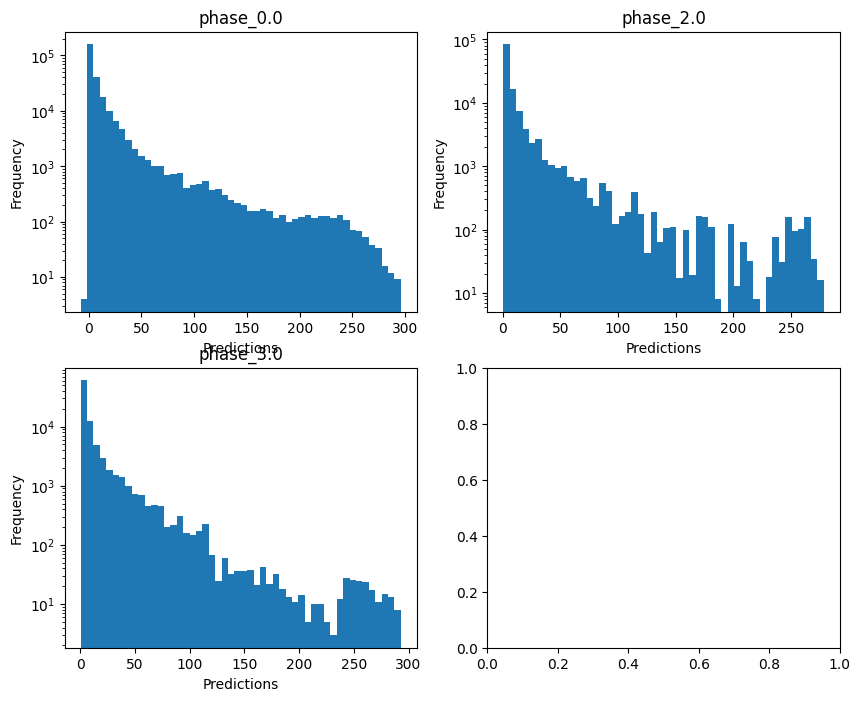

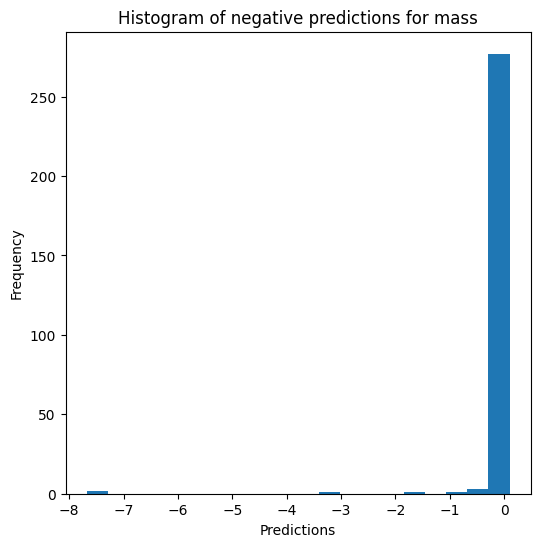


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9994380170169319
  RMSE :  0.013519559302933436
  MAE :  0.009938621244050263
  MedAE :  0.007491853811901372
  CORR :  0.9997190014385369
  MAX_ER :  0.13587362960448646
  Percentiles : 
    75th percentile :  0.013644835939643087
    90th percentile :  0.021510246049467083
    95th percentile :  0.027550861808119744
    99th percentile :  0.042245766054644064

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9992306813494213
  RMSE :  0.013622268924976732
  MAE :  0.010655676089390474
  MedAE :  0.008759958874671847
  CORR :  0.9996159124585666
  MAX_ER :  0.07363099087913305
  Percentiles : 
    75th percentile :  0.015141496303952562
    90th percentile :  0.02219107123655535
    95th percentile :  0.02704115847432653
    99th percentile :  0.03758513399808328

radius results for t

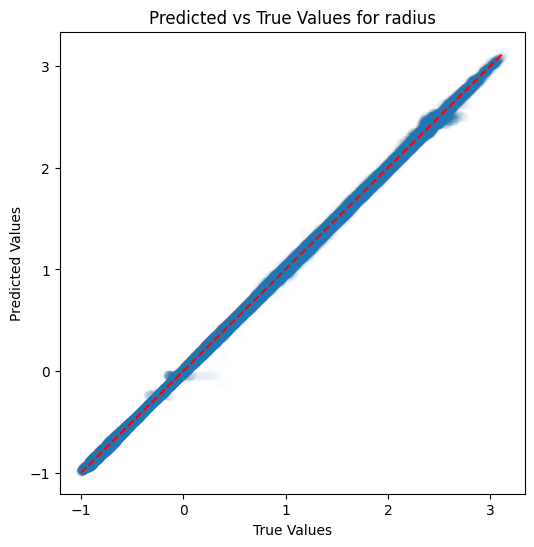

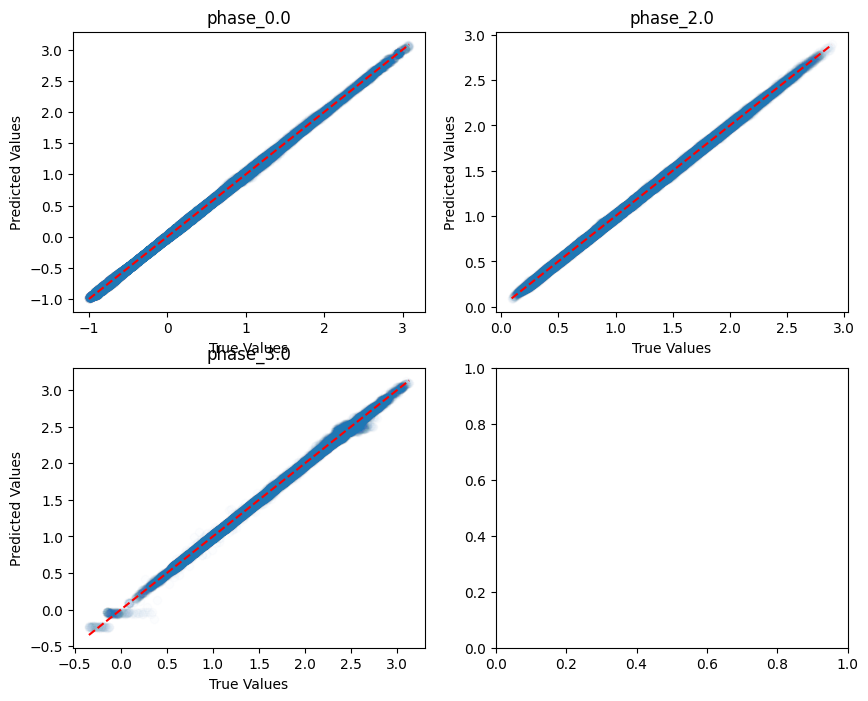

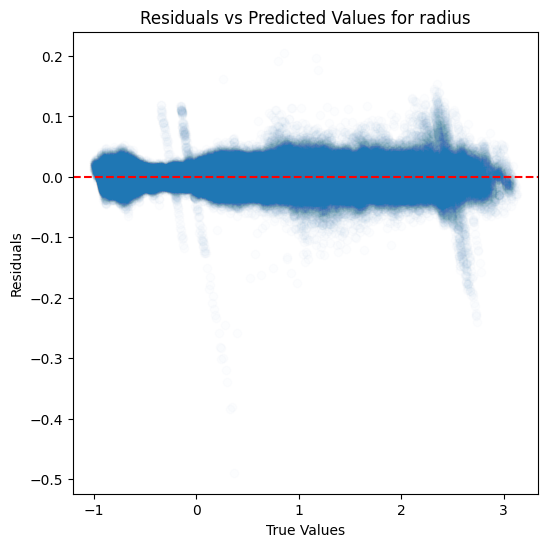

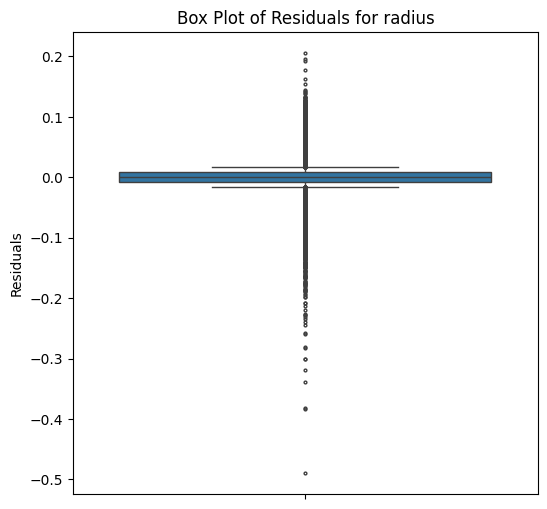

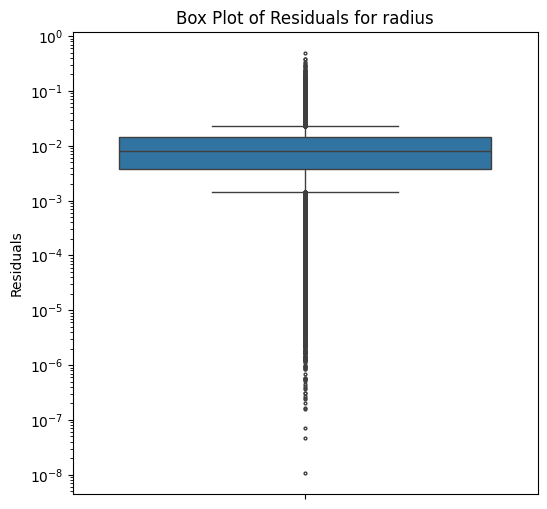

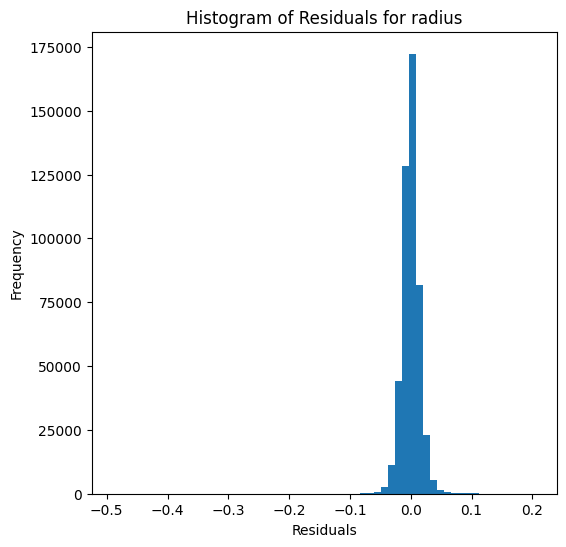

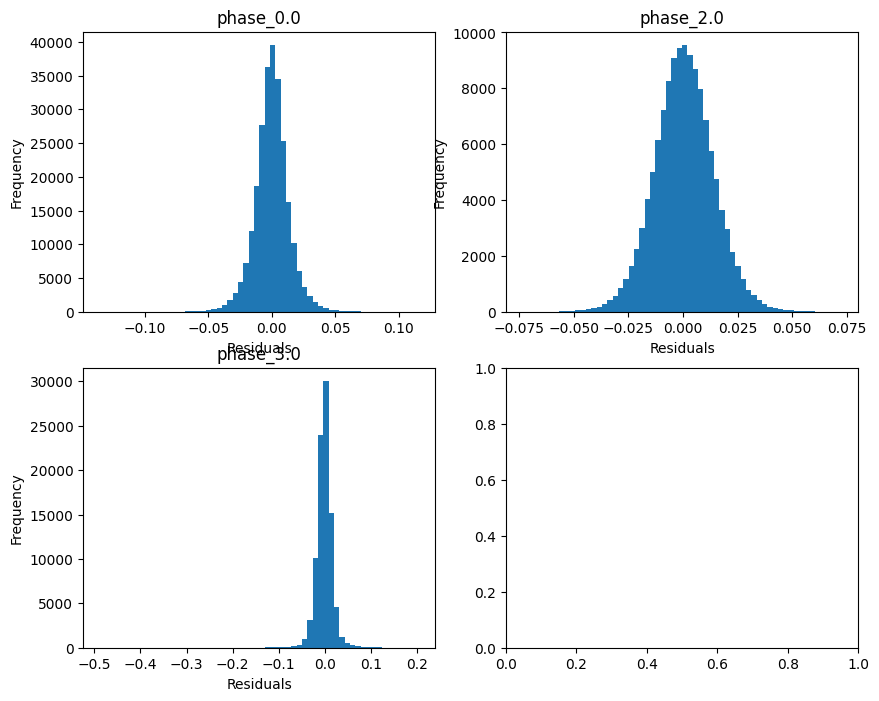

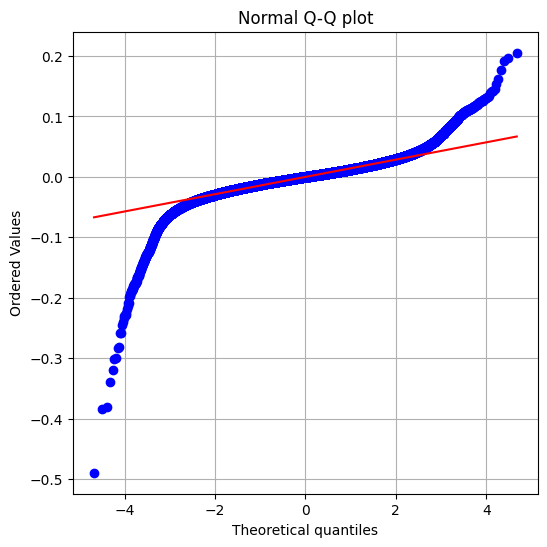

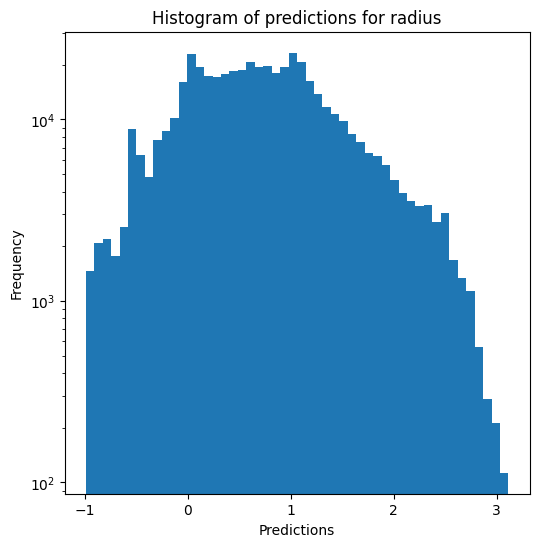

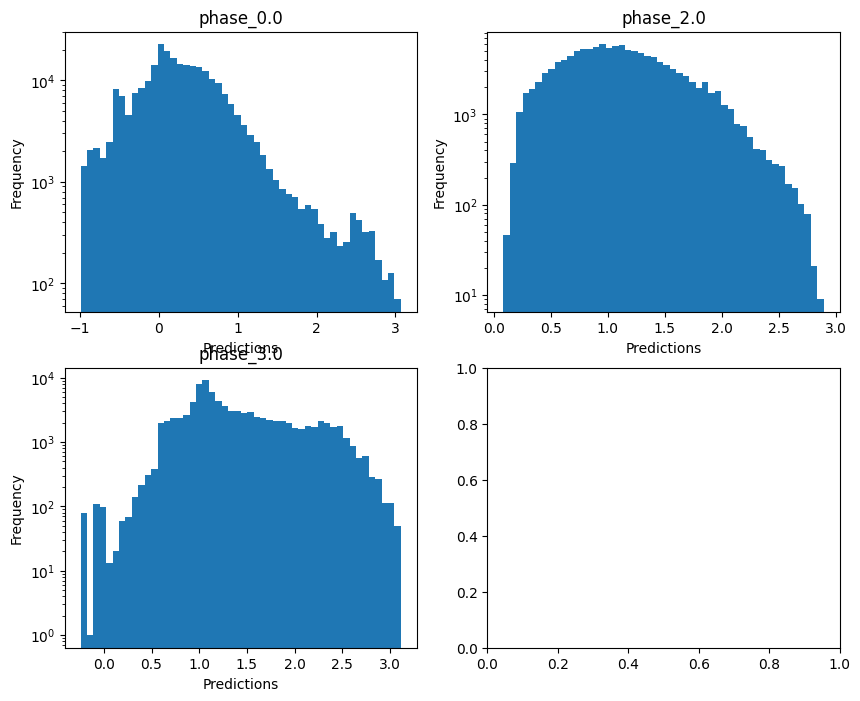

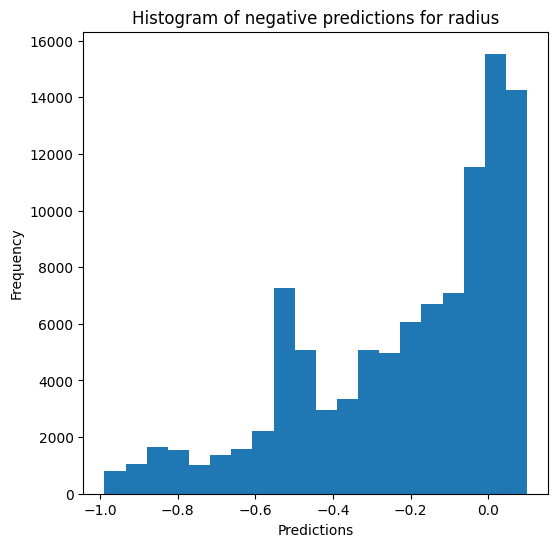

Saving results...


In [18]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### Multi-layer perceptron

In [19]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9717157238872854
  RMSE :  4.42990332226951
  MAE :  1.3941903496870511
  MedAE :  0.36905463230786684
  CORR :  0.9860617427522443
  MAX_ER :  109.7160464929029
  Percentiles : 
    75th percentile :  0.8362500580269306
    90th percentile :  2.87139985919219
    95th percentile :  5.898459746224156
    99th percentile :  19.7611334435546

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.990929974425174
  RMSE :  2.830747683224372
  MAE :  0.9162726002071936
  MedAE :  0.30079586081162146
  CORR :  0.9955996860365472
  MAX_ER :  64.98351037325284
  Percentiles : 
    75th percentile :  0.5768347342141804
    90th percentile :  1.6866561017336061
    95th percentile :  3.728625118689947
    99th percentile :  12.959241859447957

mass results for 

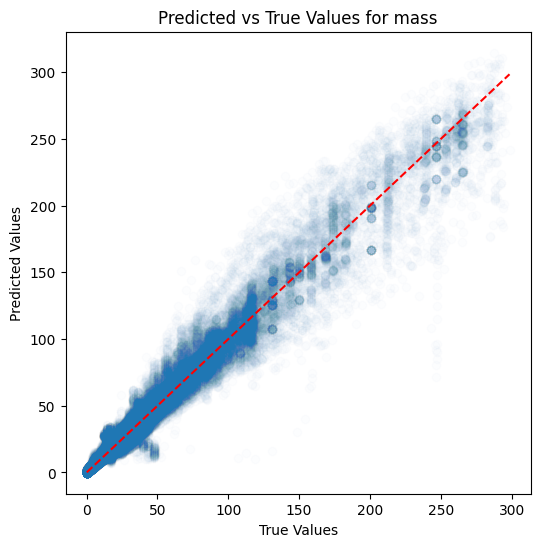

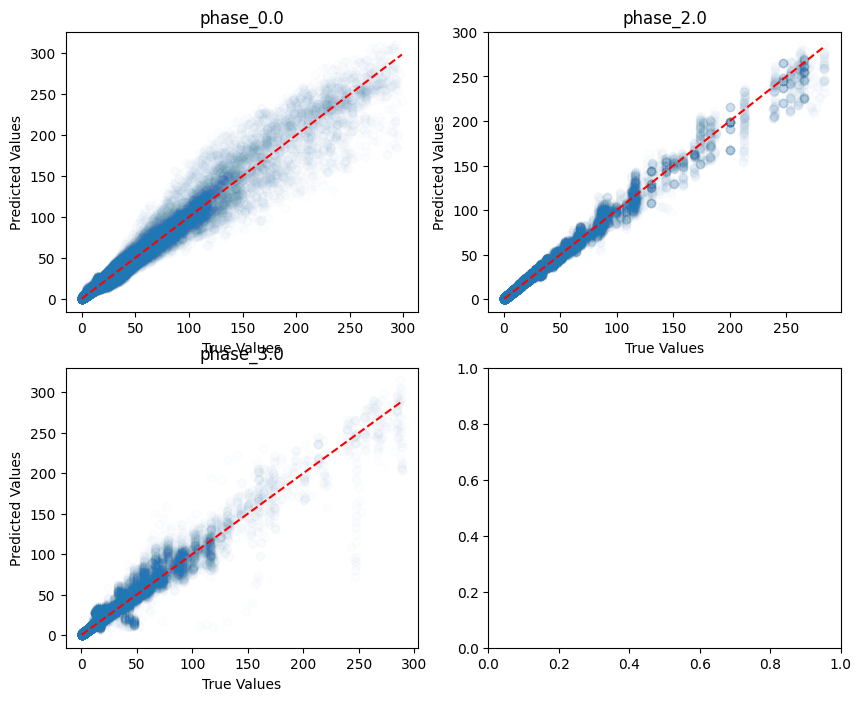

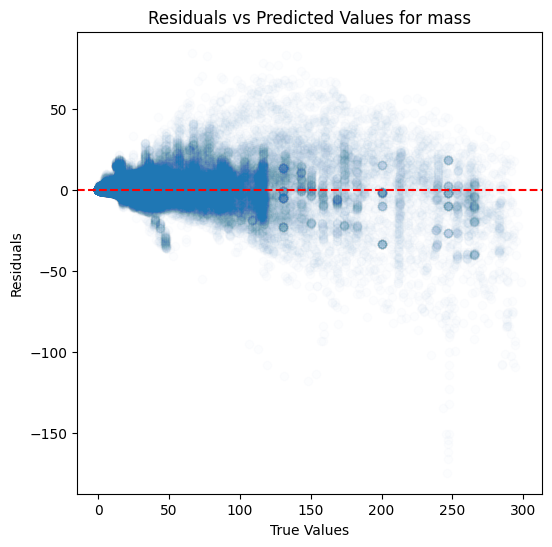

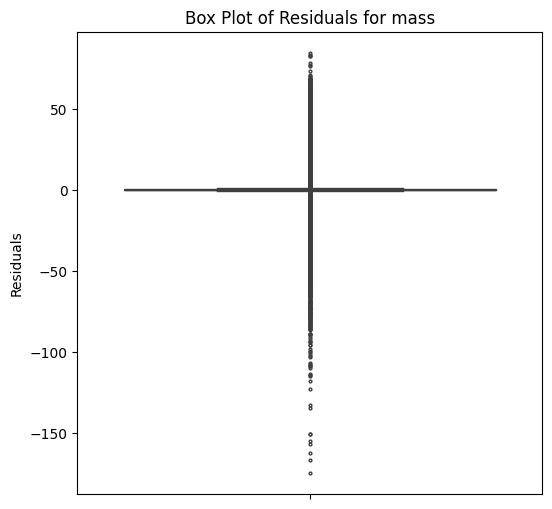

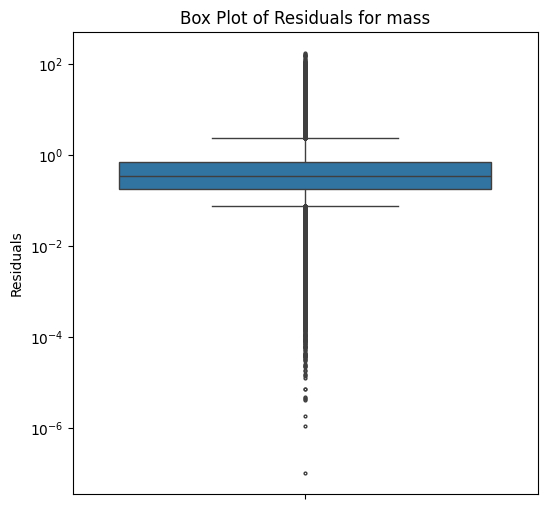

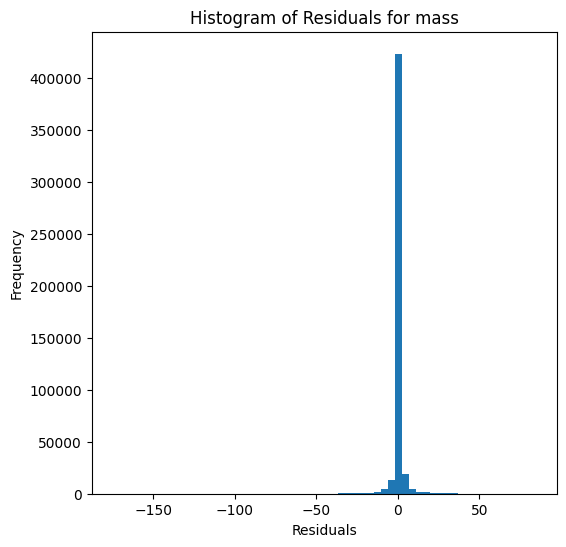

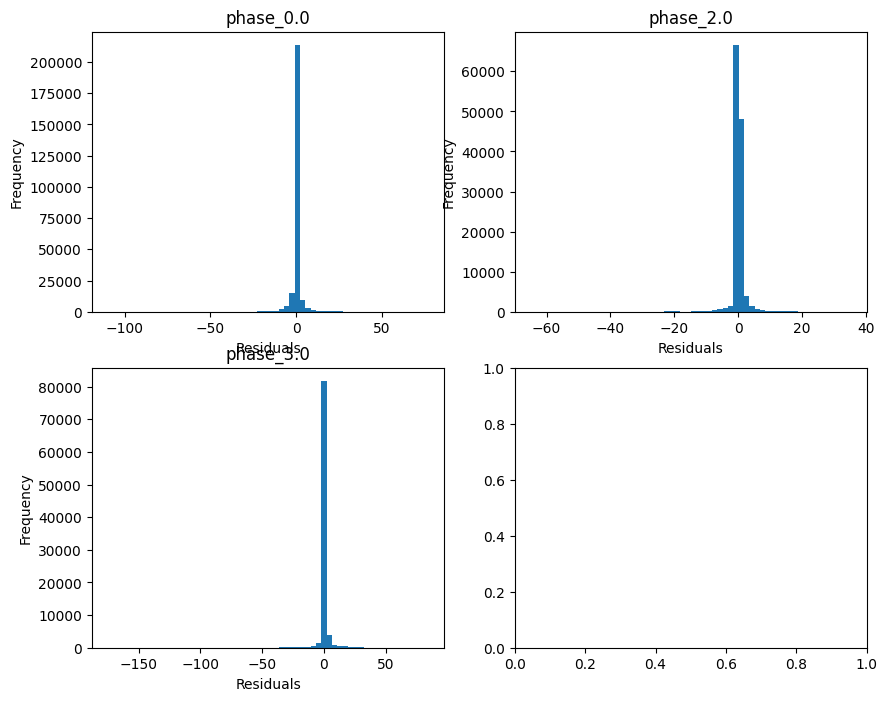

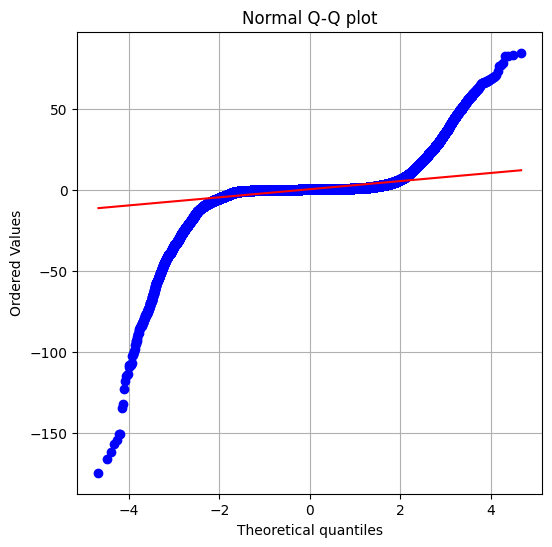

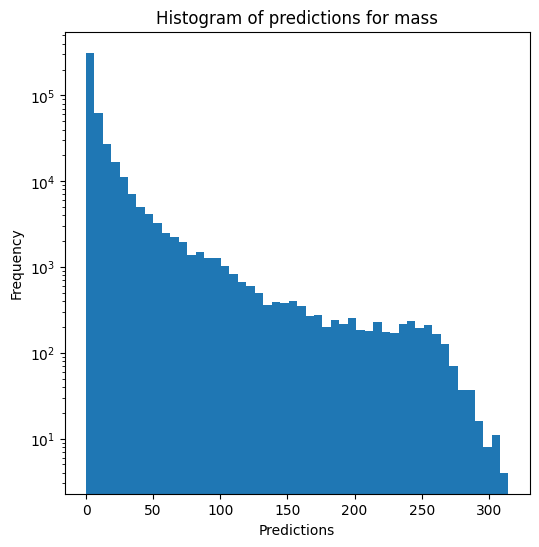

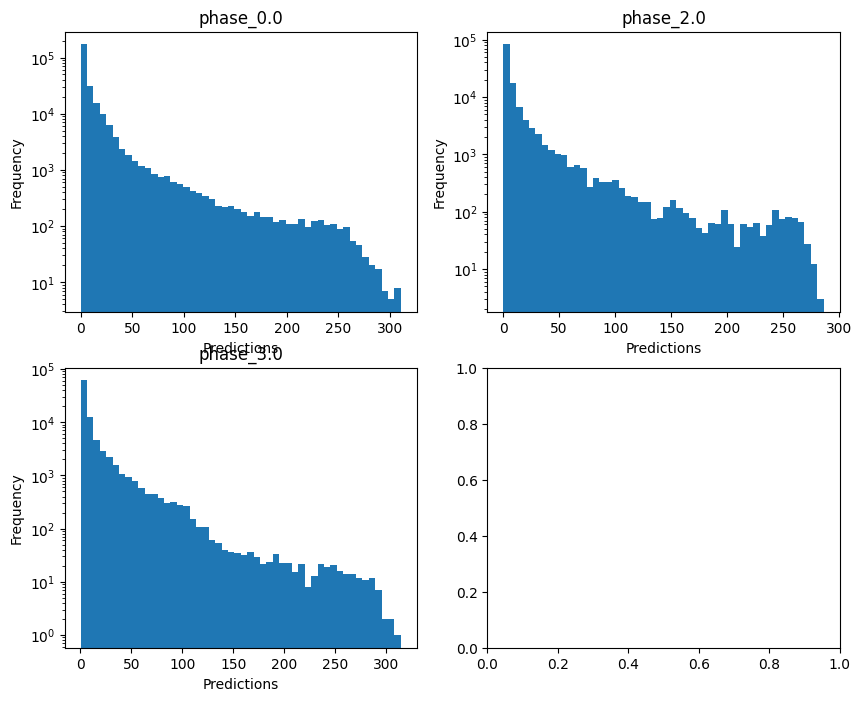

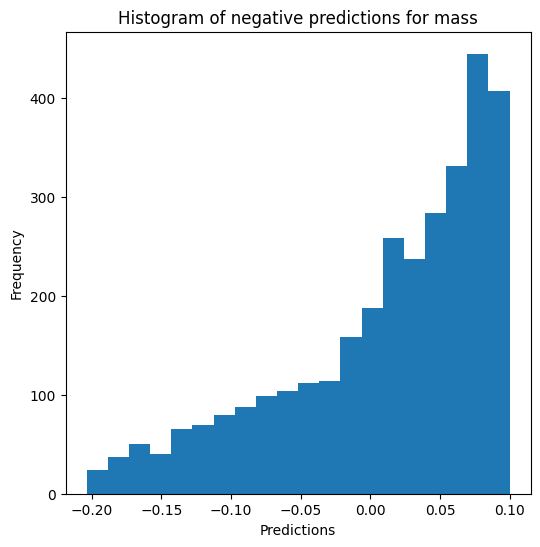


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9874097628400822
  RMSE :  0.06503199695727688
  MAE :  0.04951096152111625
  MedAE :  0.03932660883478051
  CORR :  0.9936897796640443
  MAX_ER :  0.4089455410009297
  Percentiles : 
    75th percentile :  0.06805373793471384
    90th percentile :  0.10505661261270421
    95th percentile :  0.1326780133924545
    99th percentile :  0.1963782320048394

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.984995693437375
  RMSE :  0.06316325109762302
  MAE :  0.049173813775930476
  MedAE :  0.039733514968266714
  CORR :  0.992574201430493
  MAX_ER :  0.3686245629646292
  Percentiles : 
    75th percentile :  0.07102910155919484
    90th percentile :  0.10402221841382318
    95th percentile :  0.12406398022879524
    99th percentile :  0.17081891061097115

radius results for the phase catego

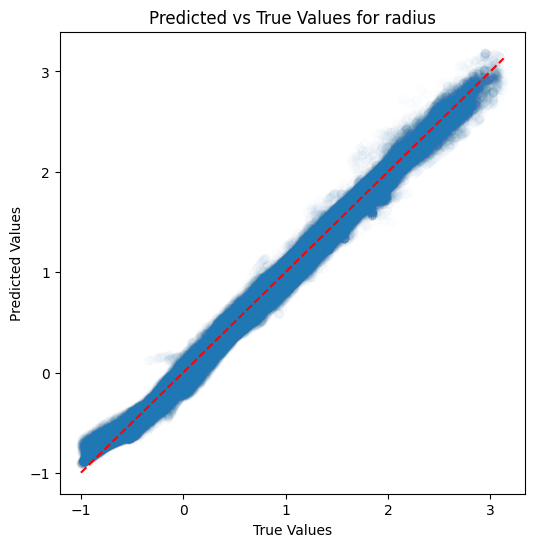

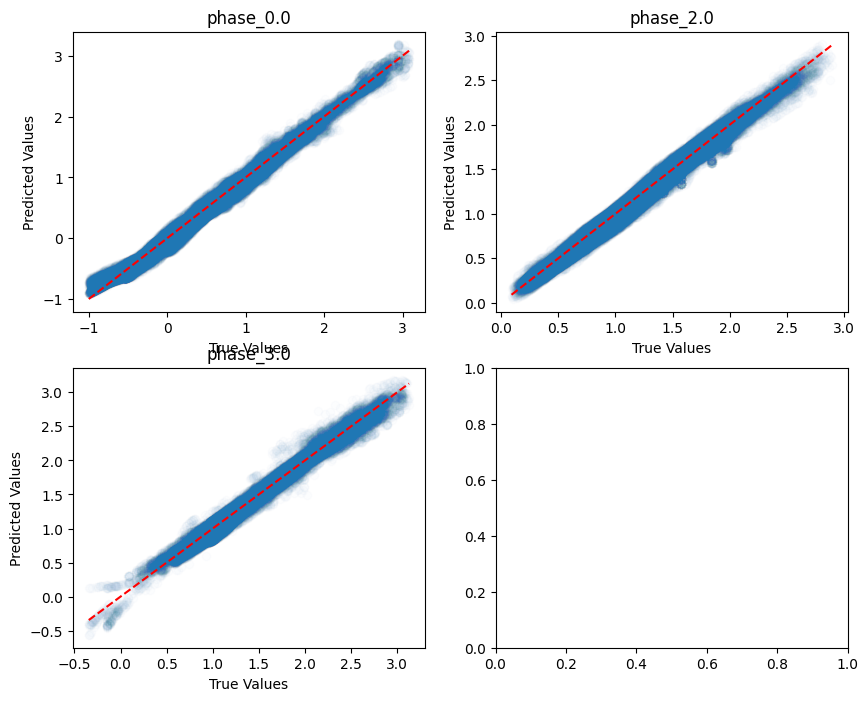

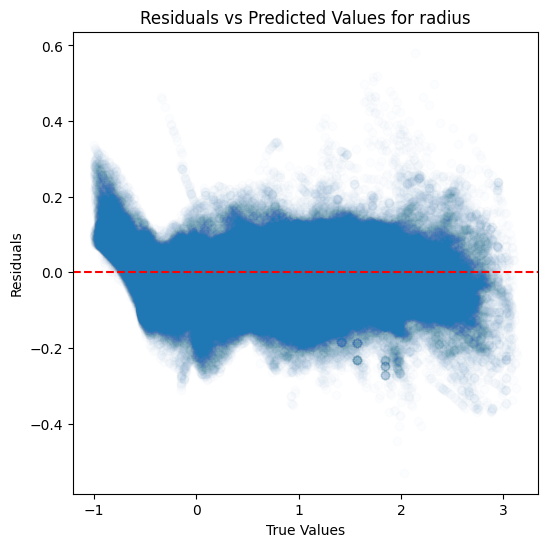

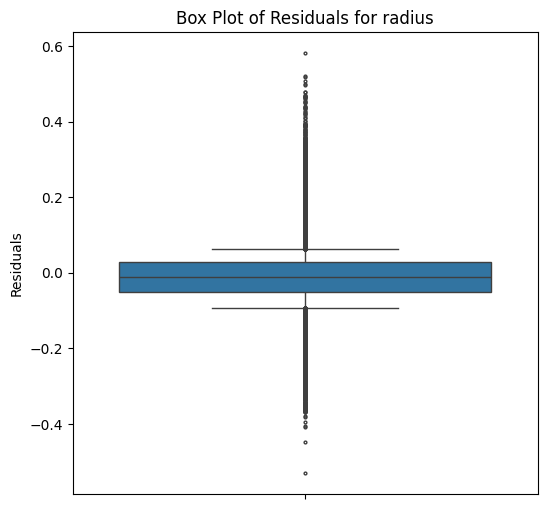

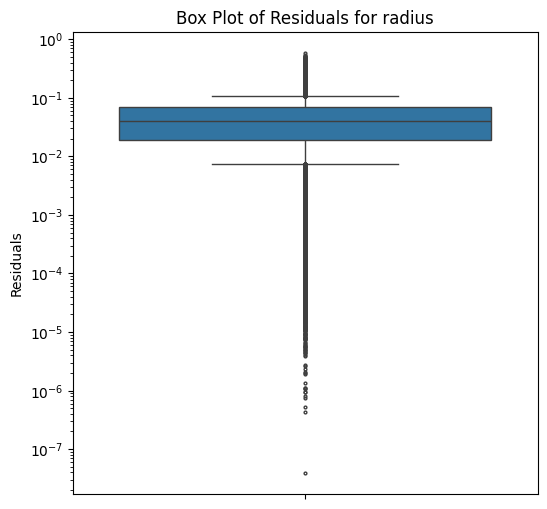

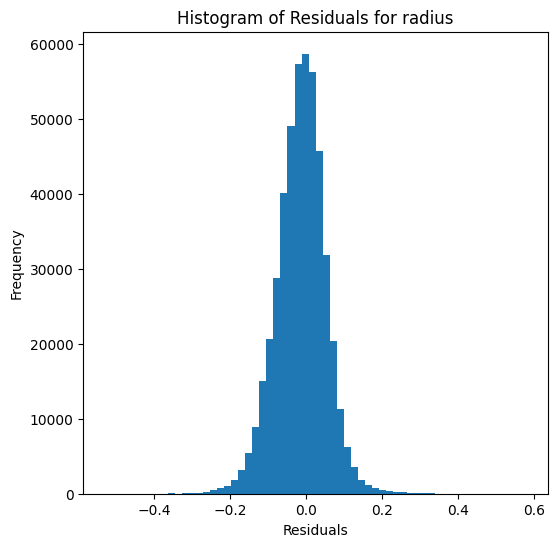

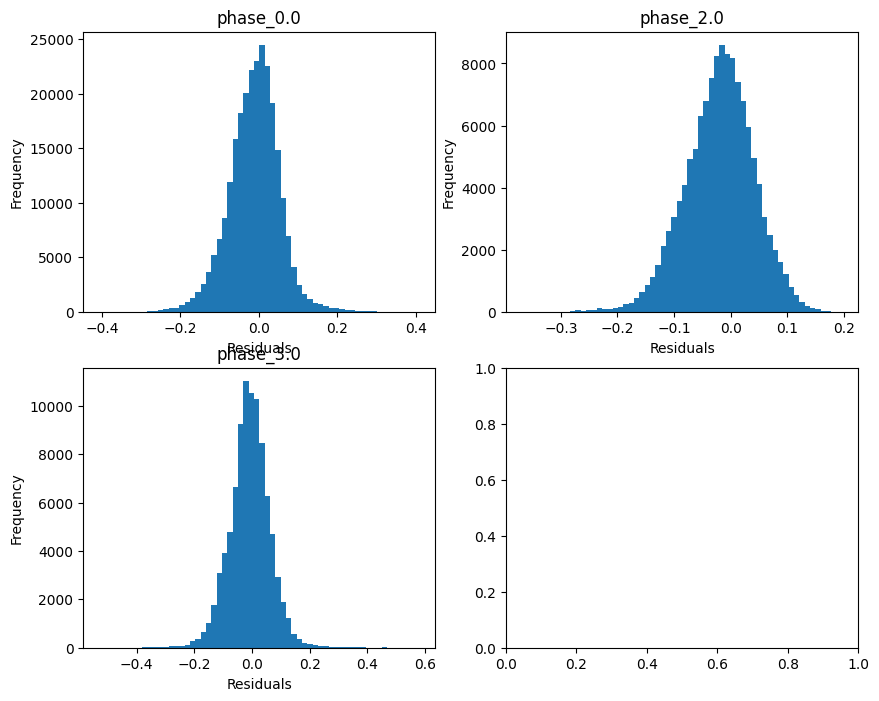

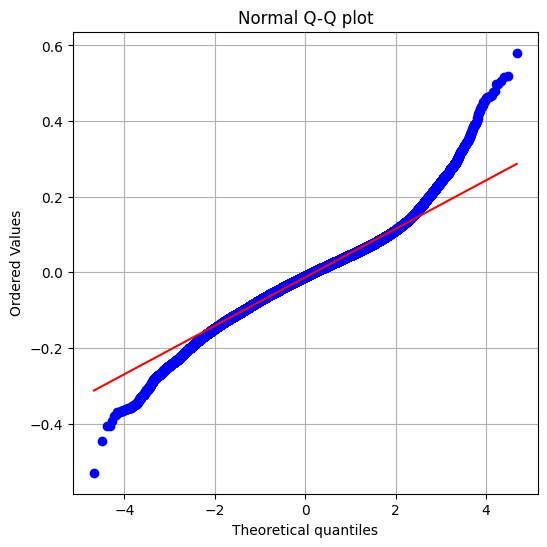

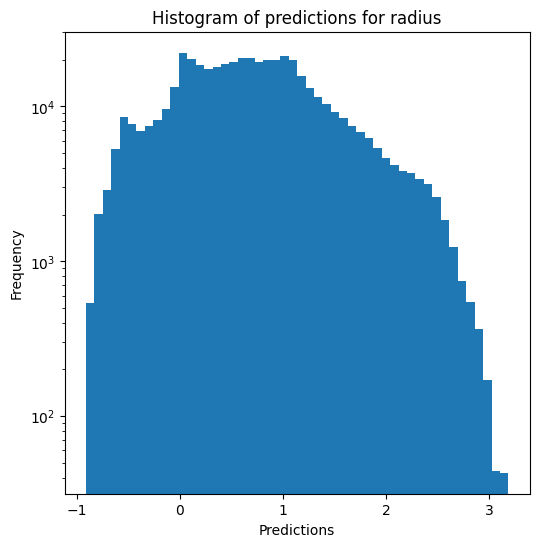

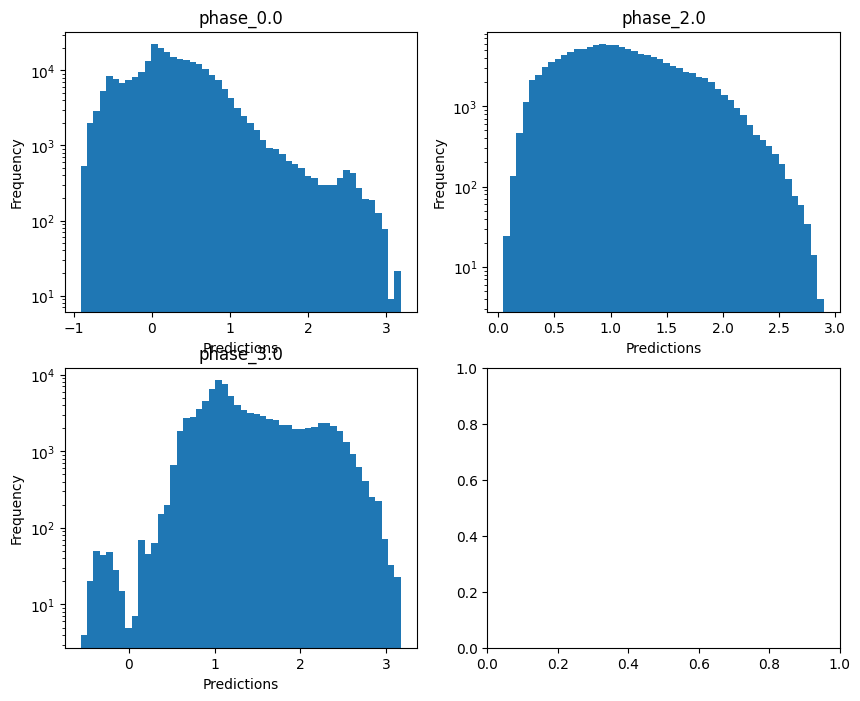

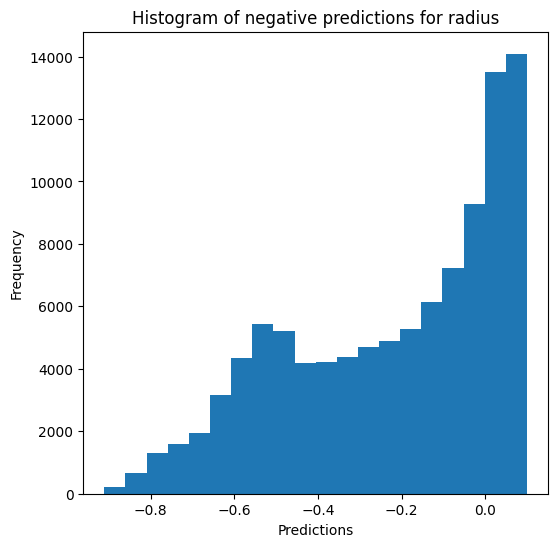

Saving results...


In [20]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon